
# **Florence-2: Language-Guided Grasp-Relevant Point Prediction**

---

## **1. About This Lab Notebook**

This Lab Notebook serves as a comprehensive companion to our project's final report. Additionally, it acts as a study guide to dive deep into our chosen project's concepts: Computer Vision (CV) with a specific focus on Vision-Language Models (VLMs).

It covers the scope of our comparative study, general domain knowledge, and an educational exploration into the architecture, evaluation, and zero-shot capabilities of our chosen model: **Florence-2**.

This notebook is designed for a broad audience, including fellow students, roboticists, machine learning engineers, professionals, and curious individuals. It will walk you through our project's:

1. **Abstract and Objectives**
2. **Theoretical background and literature**
3. **Methods and Florence-2 Python inference pipeline**
4. **Results via detailed data analysis and visualization**
5. **Final summary of our findings**
6. **Appendix: AI/ML Program Alignment & Florence-2 Extended Capabilities**


---

## **2. Study Guide: The Anatomy of an Abstract**

The writing of our **final report's abstract** followed the guidelines taught during our **ENGR 521 Zoom lecture (Week 8 slides: Anatomy of an Abstract)**. Breaking down technical writing into these distinct logical steps ensures that our chosen project's problem, methodology, and significance are stated with clarity. This allows readers to digest the information quickly.

Here is the 6-step framework we utilized to construct our abstract:

1. **The Hook (Big Picture):** One sentence establishing the broader context, the core question, and why the field is important.
2. **The Gap (State of the Art):** A brief summary of what currently exists, highlighting a specific unknown, limitation, or performance gap.
3. **The Approach:** An explanation of the perspective or motivation used to address the gap. Why is this new method a good idea?
4. **The Turn (The "We Did"):** Exactly one sentence explaining precisely what the project accomplished (an elaboration of the title).
5. **The Results:** A concise list of 2 to 4 major findings or metrics, allocating one sentence per finding.
6. **The Close:** A final sentence explaining the broader impact and why the multiple groups mentioned in our project (e.g., engineers, researchers, caregivers) should care.



---

## **3. Abstract**

Robotic grasping remains a challenging open problem, particularly when manipulation must be guided by natural language instructions. Modern **vision-language models** (VLMs) demonstrate strong semantic understanding. Yet, translating linguistic object references into the **pixel-precise spatial localization** required for contact-rich manipulation represents a fundamental bottleneck [[15]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1). To address this gap, our approach contrasts a baseline semantic model against models with explicit spatial pretraining. For this evaluation, we utilize a subset of the **PixMo-Points** dataset featuring everyday household objects. In this project, we present a comparative study evaluating three state-of-the-art VLM architectures - **CLIP, Grounding DINO, and Florence-2** - on the task of language-guided **grasp-relevant point prediction**.

Our results demonstrate that spatial pretraining is the fundamental determinant of pixel-precise localization performance. Specifically, Grounding DINO achieves a dominant **32.8%** success rate with a median error of 7 pixels. In contrast, the generalist sequence-to-sequence Florence-2 model reaches **22.4%**, while a structurally modified spatial-heatmap CLIP baseline achieves only **6.0%**.

Finally, we show that while all architectures exhibit robustness to prompt phrasing, they universally fail on small, featureless objects. This shared limitation suggests that physical object geometry dictates baseline task difficulty. This study highlights that dense spatial supervision is a prerequisite for roboticists and engineers deploying VLMs in robotic manipulation systems, including assistive caregiving applications.

<br>

*(Refers to: [[15]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1) G. Tziafas and H. Kasaei, "Towards Open-World Grasping with Large Vision-Language Models," *arXiv preprint arXiv:2406.18722*, 2024.)*


---

## **4. Introduction**

Every year, millions of elderly and disabled individuals struggle to perform simple activities like picking up a glass of water or retrieving their medication. These are moments that caregivers must drop everything to address which is costing the U.S. healthcare system approximately **$177.5 billion** in 2026 [[16]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1) and quietly eroding patients' sense of independence and dignity. If a robot could simply listen to a language instruction and act on it precisely the way a human assistant would, it could free caregivers and give people back their autonomy, safety, and quality of life. The deployment of VLMs in assistive robotics involves critical safety risks, as pixel-level miscalculations during grasping can result in patient injury. Our project investigates Computer Vision (CV) by focusing on **Vision-Language Models** (VLMs) - AI systems that process both images and text - for the task of grasp-relevant 2D point prediction. We aim to move beyond coarse bounding-box localization toward predicting **precise (x, y) pixel coordinates** that are meaningful for robotic interaction. Our goal is to achieve high-precision, language-guided grasp-relevant point prediction to improve lives, increase productivity. This final report details our progression from the conceptual project to the outlined comparative results among the models. Toward this vision, our project takes a first step by asking a fundamental question: **Can language make a robot not just see an object, but understand how to interact with it the way a human would?**

This project pursues three concrete objectives. First, we benchmark three vision-language architectures, a supervised CLIP-based regression head, and two zero-shot models (Grounding DINO and Florence-2) on the task of predicting precise (x, y) grasp-relevant pixel coordinates from RGB images alone. Second, we evaluate whether natural language prompt variation (e.g., "point to" versus "grasp the") causes statistically meaningful shifts in predicted interaction points, testing whether these models genuinely understand language or merely respond to visual patterns. Third, we establish a reproducible evaluation framework using pixel error, normalized error, and success rate across 48 object categories that future work can build on as models and datasets improve.

We draw on **GraspMoLMo** (Deshpande et al., 2025) [[14]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1) as a motivating reference, as it demonstrates that natural language instructions can guide semantically meaningful grasp point selection (e.g., grasping a teapot handle vs. its body). While GraspMoLMo relies on RGB-D input and a large-scale synthetic dataset, our work investigates how much language-guided grasp localization is achievable from **RGB images** alone, using real-world annotations from PixMo-Points [[7]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1) a deliberate simplification to isolate the role of visual-language grounding without depth sensing.



---

### **Introduction: Key Points Table Summary**

| Project Details | Key Takeaways |
| --- | --- |
| **Background & Motivation** | <br> Addresses the **$177.5 billion** healthcare burden by developing technology to restore patient autonomy, dignity, and lessen caregiver burnout. <br> <br> |
| **Primary Technical Goal** | <br> Moves beyond coarse bounding boxes to predict **precise (x, y) grasp-relevant pixel coordinates** using VLMs limited strictly to RGB images. <br> <br> |
| **Core Objectives** | <br> **1.** Benchmark three VLM architectures (CLIP, Grounding DINO, Florence-2). <br> <br> **2.** Evaluate the impact of natural language prompt variations on grasp targeting. <br> <br> **3.** Establish a reproducible evaluation framework across 48 object categories. <br> <br> |

<br>

### **Project's Ethical Considerations Summary**

| Benefits | Risks |
| --- | --- |
| <br> <br> • Restores patient autonomy, independence, and dignity. <br> <br> • Improves overall quality of life for the elderly and disabled. <br> <br> • Lessens caregiver burnout by freeing them from repetitive physical tasks. <br> <br> | • Introduces critical safety risks in human-robot interaction within assistive care. <br> <br> • Pixel-level miscalculations during physical grasping can result in patient injury. |



---

## **5. Background**

### **5.1 Vision-Language Models**

Vision-language models learn joint representations of images and text through large-scale contrastive or generative pretraining.

**CLIP** (Contrastive Language-Image Pre-training) [[8]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1) trains a dual-encoder - a ViT [[9]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1) image encoder and a Transformer text encoder - to align matched image-text pairs via **contrastive loss**. Its patch tokens can be queried via **cross-attention** and reinterpreted as a **spatial heatmap** to recover localization structure otherwise lost by global pooling.

**Florence-2** [[12]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1) is a generalist vision-language model that frames all vision tasks as a **sequence-to-sequence** problem, jointly encoding image patches and text tokens through a transformer encoder-decoder. It generates discrete **location tokens** via **autoregressive decoding**, from which bounding box coordinates are extracted and converted to grasp points via **centroid extraction**.

**Grounding DINO** [[11]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1) is an **open-set vision-language detector** that predicts **text-conditioned bounding boxes** from **text prompts** and images. It uses a **Transformer-based image encoder**, a **text encoder**, and **cross-modal interaction** to align textual queries with image regions. In our method, the **highest-scoring box** is used to estimate the **grasp point**.

<br>

### **5.2 Evaluation Metrics**

We evaluate all models using the following metrics. The first three are base metrics. The remaining four are derived from them.

**Pixel Error (L2 Norm).** Euclidean distance between predicted and ground-truth grasp coordinates:
$$E_{\text{pixel}} = \sqrt{(x_{\text{pred}} - x_{\text{gt}})^2 + (y_{\text{pred}} - y_{\text{gt}})^2} \tag{1}$$
where $(x_{\text{pred}}, y_{\text{pred}})$ are the coordinates of the predicted grasp point and $(x_{\text{gt}}, y_{\text{gt}})$ are the coordinates of the ground-truth annotation.

**Normalized Pixel Error.** Pixel error normalized by image diagonal for resolution-invariant comparison:
$$E_{\text{norm}} = \frac{E_{\text{pixel}}}{\sqrt{w^2 + h^2}} \tag{2}$$
where $w$ and $h$ are the width and height of the image, respectively, defining the diagonal length of the spatial domain.

**Success Rate.** Fraction of predictions within $\tau = 50$ px of ground truth, where $\mathbf{1}[\cdot]$ is the indicator function:
$$S_{\text{rate}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}\!\left[ E_{\text{pixel},i} < \tau \right] \tag{3}$$
The $50$ pixel success threshold was chosen to balance image-resolution considerations, annotation variability, and practical tolerance requirements for grasp localization.

**Prompt Sensitivity.** Standard deviation of pixel errors across $P$ prompt phrasings for the same object, averaged over $M$ instances. High sensitivity indicates unstable predictions:
$$\text{Sensitivity} = \frac{1}{M} \sum_{j=1}^{M} \sigma\!\left(\{ E_{\text{pixel},j,p} \}_{p=1}^{P}\right) \tag{4}$$
where $M$ is the number of object instances and $\sigma(\cdot)$ denotes standard deviation.

**Prompt Consistency.** Sensitivity normalized by image diagonal and subtracted from $1$. Values near $1$ indicate stable predictions across prompt variations:
$$\text{Consistency} = 1 - \frac{\text{Sensitivity}}{\sqrt{w^2 + h^2}} \tag{5}$$

**Per-Category Error.** Mean pixel error per object category, revealing which object types are harder to localize:
$$\bar{E}_c = \frac{1}{N_c} \sum_{i \in \mathcal{C}_c} E_{\text{pixel},i} \tag{6}$$
where $N_c = |\mathcal{C}_c|$ is the number of samples in category $c$. This reveals which object types are harder
to localize for each model.

**Per-Prompt Error.** Mean pixel error per prompt template, revealing whether certain phrasings favor specific architectures:
$$\bar{E}_p = \frac{1}{N_p} \sum_{i \in \mathcal{P}_p} E_{\text{pixel},i} \tag{7}$$
where $N_p$ is the number of samples evaluated with prompt $p$.



---

## **6. Methods**

### **6.1 Dataset**

We use a subset of PixMo-Points [[7]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1), containing 914 samples across 48 household object categories (cups, bottles, plates, etc.) collected via a pointing-based annotation method. Each sample consists of an RGB image, a natural-language object label, and a ground-truth grasp point $(x^*, y^*)$. The dataset is split into 548 training, 183 validation, and 183 test samples.



<br>

### **6.2 Prerequisites & Environment Setup**

To ensure reproducibility across all three model architectures, we utilize a modular dependency installation. Please ensure the following configurations are set prior to model inference:

* **Python** 3.8+
* **CUDA** compatible GPU (Highly recommended for inference/training)
* **Git**

### **CLIP**

```bash
!pip install -q torch torchvision transformers pillow matplotlib tqdm
```

```python
MODEL_NAME = "openai/clip-vit-base-patch16"
```

### **Grounding DINO**

```bash
!pip -q install "transformers>=4.51,<4.58" "accelerate>=0.30,<1.0" "pillow>=10,<12" matplotlib
```

```python
MODEL_ID = "IDEA-Research/grounding-dino-tiny"
```

### **Florence-2**

```bash
!pip install -q transformers==4.49.0 accelerate==0.30.1 einops==0.8.0 datasets pillow matplotlib requests
```

```python
model_id = "microsoft/Florence-2-large"
```



### **6.3 Project Architecture**

![Project Architecture](https://raw.githubusercontent.com/priyagautham28/grasp-point-prediction/main/outputs/florence2_final_report/pipeline_diagram.png)

*Figure 1: Project Architecture.*

Figure 1 illustrates the unified evaluation pipeline. Each input image and natural language label is preprocessed from PixMo-Points and passed in parallel through all three models, with outputs parsed into a standardized JSON format storing predicted coordinates, pixel error, and derived metrics for comparative analysis.



### **6.4 CLIP**

Explored four architectural variants of increasing complexity, each addressing a limitation of the previous design (Figure 2).

The baseline (Arch 01) averaged all patch features into a single global vector and passed it through an **MLP regression** head with batch normalization between hidden layers to stabilize training, framing grasp-point prediction as a nonlinear least-squares problem minimizing **MSE loss** between predicted and ground-truth $(x, y)$ coordinates optimized using **Adam with backpropagation**. The contrastive pretraining objective itself is a form of **cross-entropy** over pairwise similarity scores, but averaging collapsed all spatial information, yielding only **1.6%** success rate.

Arch 02 introduced **cross-attention** via scaled dot-product attention $\textbf{softmax}(QK^\top/\sqrt{d})V$, allowing the text to attend over patch tokens rather than a pooled average, improving to **2.7%** though compressing attended features into a single vector still limited localization precision.

The major improvement came with Arch 03, which replaced direct coordinate regression with a **spatial heatmap** formulation each patch is assigned a probability score and the final coordinate computed as a softmax-weighted sum $\hat{y} = \sum_i w_i \cdot c_i$, preserving spatial structure throughout the network rather than collapsing it before prediction, achieving **6.0%** success rate. Arch 04 increased patch resolution from a **7x7 to a 14x14 grid**, analogous to refining a finite element mesh, reducing mean error from **282px to 267px** while maintaining **6.0%** success.

![CLIP Architecture](https://raw.githubusercontent.com/priyagautham28/grasp-point-prediction/main/outputs/florence2_final_report/clip_arch.png)

*Figure 2: **Four CLIP architecture variants evaluated progressively.** The final design (Arch 04, Patch-16) achieves 6.0% success rate and 267px mean error, selected as the CLIP baseline for comparative evaluation.*



### **6.5 Florence-2**

![Florence-2 Architecture](https://raw.githubusercontent.com/priyagautham28/grasp-point-prediction/main/outputs/florence2_final_report/florence2_project_architecture.png)

*Figure 3: **Architecture and evaluation pipeline for Florence-2 zero-shot grasp point prediction.** The model processes images and text prompts (utilizing the `<CAPTION_TO_PHRASE_GROUNDING>` prefix) into joint embeddings. These are decoded by a sequence-to-sequence transformer into location tokens. Dual-prompting was implemented to evaluate sensitivity. Adapted from [[13]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1).*

Florence-2 is a **unified vision-language model** from Microsoft that frames all vision tasks - **detection, captioning, grounding, and segmentation** - as a sequence-to-sequence problem [[13]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1). This framework provides a practical example of Designing an Architecture [[4]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1). Unlike the CLIP baseline, we conducted a pure zero-shot evaluation for Florence-2 without training a custom regression head. This approach effectively compares a globally generalized model against our locally supervised baseline. Though evaluated **zero-shot**, its foundational weights were established using the **SGD and Adam optimizers** [[2], [3]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1). It was trained on the massive **FLD-5B** dataset, which is a direct application of Curating Training Data [[4]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1).

As illustrated in Figure 3, the spatial localization task begins by passing the input image (e.g., a watch) through an encoder to generate visual embeddings. In parallel, we construct a text sequence utilizing the `<CAPTION_TO_PHRASE_GROUNDING>` prefix alongside a **dual-prompting method**. Specifically, we ask the model to "Point to the..." versus "Grasp the..." target object. Both embeddings are passed through the model's **transformer encoders and decoders**. Florence-2 draws on the principles of probabilistic modeling and objective minimization. It generates outputs by calculating the **conditional probability of each subsequent token given the visual input and prior tokens**. At its output layer, it classifies over a **high-dimensional token vocabulary, optimizing its predictions by minimizing cross-entropy loss**  [[4]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1). This **Maximum Likelihood Estimation (MLE)** [[2]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1) maps probability distributions to generate discrete location tokens representing bounding boxes. We subsequently convert these boxes into precise $(x, y)$ coordinate predictions via **centroid extraction**.

Because Florence-2 requires deliberate prompt engineering, we utilized **Hypothesis Testing** [[2]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1) to evaluate prompt sensitivity. This allowed us to determine if altering our exact phrasing causes a statistically significant shift in error rates. The paired evaluation on the outputs of the dual prompts yielded a *p*-value of **0.622**, meaning we failed to reject the null hypothesis. This demonstrates that the model is **highly robust and localizes** consistently regardless of the specific phrasing used. In final evaluation, applying a 50-pixel radius threshold via Euclidean distance, this architecture achieved a **22.4%** success rate. This result demonstrates a massive improvement over the structurally modified CLIP baseline.



### **6.6 Grounding DINO**

Grounding DINO is a **zero-shot vision-language object detector** that uses a **Transformer-based architecture** and **cross-modal interaction** to align **text prompts** with image regions and predict **text-conditioned bounding boxes**. In this work, we use it only for **inference**, but its pretrained parameters were learned through **backpropagation**, **AdamW optimization**, **cross-entropy loss**, **L1 box loss**, and **GIoU loss**, connecting our approach to **deep neural representation learning**, **objective minimization**, and **statistical learning**.

As shown in **Figure 4**, the workflow begins with a task-specific **text prompt** and an **input image**. Grounding DINO jointly processes the **visual** and **language inputs** to generate candidate **bounding boxes** and **confidence scores** for the queried object. We select the **highest-confidence box** and use its center as the predicted **grasp point**. This **two-stage process** identifies the object region before estimating the grasp point, making the prediction easier to interpret.

For **evaluation**, we analyzed how **prompt choice** affected validation performance. Grounding DINO was sensitive to **prompt wording**, with different prompts producing noticeably different localization results. The prompt **"point to the {label}."** achieved the **lowest mean pixel error** of **184.5 px** and a **validation success rate** of **38.8%**, so we selected it for testing. On the test split, it achieved a **mean pixel error** of **215.354 px**, a **mean normalized pixel error** of **0.126**, a **success rate** of **32.8%**, and a **detection rate** of **88.5%**. These results show that Grounding DINO was effective at detecting **target objects**, but using the **bounding-box center** as a proxy for the annotated **grasp point** limited **localization accuracy**.

![Grounding DINO Architecture](https://raw.githubusercontent.com/priyagautham28/grasp-point-prediction/main/outputs/florence2_final_report/Grounding_DINO_Workflow.png)

*Figure 4: **Grounding DINO-based grasp-point prediction pipeline.** The model takes a text prompt and image as input, detects the prompted object with bounding boxes and confidence scores, and uses the center of the highest-confidence box as the predicted grasp point. Performance is evaluated against the ground-truth point using Euclidean distance.*


---

## **7. Results**

![Success Rate](https://raw.githubusercontent.com/priyagautham28/grasp-point-prediction/main/outputs/florence2_final_report/fig1_success_rate.png)

**Figure 5:** Overall grasp point localization success rate for CLIP, Grounding DINO, and Florence-2 on the 183-image test set.

![Prompt Sensitivity](https://raw.githubusercontent.com/priyagautham28/grasp-point-prediction/main/outputs/florence2_final_report/fig2_prompt_sensitivity.png)

**Figure 6:** Success rate under two prompt phrasings for each model evaluated on the validation set.

As shown in Figures 5 and 6, Grounding DINO substantially outperforms both other models with a success rate 5.5$\times$ higher than CLIP and 1.5$\times$ higher than Florence-2, highlighting the advantage of explicit spatial grounding over contrastive training. All three models are largely insensitive to prompt phrasing, with Grounding DINO showing the largest variation at only 3 percentage points, confirming that the performance gap is architectural rather than linguistic.

![Pixel Error](https://raw.githubusercontent.com/priyagautham28/grasp-point-prediction/main/outputs/florence2_final_report/fig4_pixel_error.png)

**Figure 7:** Localization pixel error across best, typical, and worst-case prediction scenarios for all three models.

![Threshold Sweep](https://raw.githubusercontent.com/priyagautham28/grasp-point-prediction/main/outputs/florence2_final_report/fig5_threshold_sweep.png)

**Figure 8:** Success rate as a function of distance threshold for all three models on the test set.

Figure 7 shows Grounding DINO achieves consistently low pixel error across all scenarios, with a best-case error of just 1px and a typical error of 7px, compared to CLIP's typical error of 17px. Florence-2 shows the highest worst-case error at 40px, suggesting its sequence-to-sequence decoding is susceptible to large localization failures on hard cases. The threshold sweep (Figure 8) confirms that at strict evaluation ($\tau \approx 3.5$), Grounding DINO achieves a 6$\times$ advantage over CLIP, narrowing to 2.1$\times$ at relaxed thresholds indicating CLIP predictions land near the correct region but lack fine-grained spatial precision.

The per-category analysis (Figure 9) reveals a shared failure mode independent of architecture. Easy objects such as bottle (Grounding DINO: 100%), watch, and shoe are large with distinctive shapes and appear frequently in pretraining data. Hard objects such as earbuds, keys, tape, and hairbrush are small and textureless, causing all three models to fail equally suggesting object structure rather than model architecture is the primary determinant of difficulty.

![Per Category](https://raw.githubusercontent.com/priyagautham28/grasp-point-prediction/main/outputs/florence2_final_report/fig3_per_category.png)

**Figure 9:** Per-category success rate for the 10 easiest and 8 hardest object categories, ranked by average success rate across all three models.


---

## **8. Summary and Future Work**

### **8.1 Summary**

This work presented a comparative benchmarking study of three vision-language model architectures, CLIP, Florence-2, and Grounding DINO, on language-guided grasp-relevant point prediction from RGB images across 48 object categories and 183 test samples from the PixMo-Points dataset. The study was motivated by the growing need for precise, language-instructable robotic manipulation in assistive caregiving contexts.

Our results demonstrate that spatial pretraining is the fundamental determinant of localization performance. Grounding DINO achieved a dominant 32.8% success rate with a median pixel error of 7 px, Florence-2 reached 22.4%, and our supervised CLIP-based spatial heatmap regressor achieved only 6.0%, confirming that contrastive pretraining lacks the spatial grounding needed for pixel-precise localization, even when augmented with cross-attention and heatmap formulations.

All three models showed negligible sensitivity to prompt phrasing, with Grounding DINO varying by just 3 percentage points and CLIP and Florence-2 remaining unchanged. Florence-2 yielded a hypothesis-test p-value of 0.622, confirming the performance gap is architectural rather than linguistic. Per-category analysis revealed a shared failure mode across all architectures: small textureless objects like earbuds, keys, and tape caused consistent failures, while Grounding DINO demonstrated exceptional category-specific performance, achieving a 100% success rate exclusively on bottles. This aligns with findings in robotic grasping benchmarks [[10]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1), where object geometry, not algorithmic sophistication, frequently dictates task difficulty.

### **8.2 Future Work**

Several directions follow naturally from the limitations identified in this study.

**Incorporating Depth Information and Fine-Tuning.** Extending to RGB-D input, as in GraspMoLMo [[14]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1), would help resolve depth ambiguity for small and textureless objects. Fine-tuning Grounding DINO and Florence-2 on datasets such as Cornell or GraspNet-1Billion would clarify whether the architectural advantage of spatially pretrained models persists under task-specific supervision.

**Broader Model Comparisons and Localization Strategies.** Benchmarking stronger open-vocabulary models (OWL-ViT, GPT-4V, LLaVA) and real-time frameworks such as You Only Look Once (YOLO) alongside segmentation-based and keypoint-based methods would enable more principled model selection. YOLO is particularly worth evaluating given its inference speed advantage for real-time robotic grasping. Establishing a standardized evaluation protocol across these architectures would enable fair and reproducible comparisons for future work.

**Extending to 6-DoF Grasp Pose Estimation.** A natural extension is full 6 Degrees of Freedom (6-DoF) gripper pose estimation, requiring reasoning about 3D object orientation and contact geometry, allowing VLMs to serve as the grounding stage in a complete grasping pipeline.

**Simulation and Real-Robot Validation.** A natural next step is validating the pipeline in simulation environments such as PyBullet or Isaac Sim, bridging toward real-robot deployment where conditions like lighting, background texture, and camera noise cannot be captured by static dataset metrics [[10]](#scrollTo=RYLTN08J7cs_&line=39&uniqifier=1). Incorporating semantic grasp region modeling would further ensure predictions are task-appropriate for caregiving applications. Ultimately, bridging language-guided point prediction and successful physical grasps remains the core challenge for deploying these systems in assistive robotics.



---

## **9. CRediT Statement**

**Priyadarshini Rajmohan:** Conceptualization, Data Curation, Methodology, Formal Analysis, Investigation (CLIP + regressor), Visualization, Writing - Review & Editing.

**Poojitha Alam:** Conceptualization, Methodology, Formal Analysis, Investigation (Grounding DINO), Visualization, Project Administration, Writing - Review & Editing.

**Jannine G. D. MacGormain:** Conceptualization, Methodology, Formal Analysis, Investigation (Florence-2), Visualization, Project Administration, Writing - Original Draft.



---

## **10. Nomenclature**

$
\begin{aligned}
\mathbf{1}[\cdot] \quad & \text{Indicator function} \\
\sigma(\cdot) \quad & \text{Standard deviation function} \\
\tau \quad & \text{Pixel distance threshold for success } (\tau = 50 \text{ px})
\end{aligned}
$

$$\textbf{C}$$

$
\begin{aligned}
\mathcal{C}_c \quad & \text{Set of all samples belonging to category } c
\end{aligned}
$

$$\textbf{E}$$

$
\begin{aligned}
E_{\text{norm}} \quad & \text{Normalized pixel error} \\
E_{\text{pixel}} \quad & \text{Euclidean pixel error (L2 Norm)} \\
E_{\text{pixel},i} \quad & \text{Pixel error for the } i\text{-th sample} \\
E_{\text{pixel},j,p} \quad & \text{Pixel error for object instance } j \text{ using prompt } p \\
\bar{E}_c \quad & \text{Mean pixel error per object category } c \\
\bar{E}_p \quad & \text{Mean pixel error per prompt template } p
\end{aligned}
$

$$\textbf{J}$$

$
\begin{aligned}
j \quad & \text{Index of a specific object instance}
\end{aligned}
$

$$\textbf{M}$$

$
\begin{aligned}
M \quad & \text{Number of object instances}
\end{aligned}
$

$$\textbf{N}$$
$
\begin{aligned}
N \quad & \text{Total number of predictions evaluated} \\
N_c \quad & \text{Total number of samples in category } c \; (N_c = |\mathcal{C}_c|) \\
N_p \quad & \text{Total number of samples evaluated with prompt } p
\end{aligned}
$

$$\textbf{P}$$

$
\begin{aligned}
P \quad & \text{Number of prompt phrasings evaluated} \\
p \quad & \text{Index of a specific prompt template} \\
\mathcal{P}_p \quad & \text{Set of all samples evaluated with prompt } p
\end{aligned}
$

$$\textbf{S}$$

$
\begin{aligned}
S_{\text{rate}} \quad & \text{Success rate fraction}
\end{aligned}
$

$$\textbf{W}$$

$
\begin{aligned}
w, h \quad & \text{Image width and height (pixels), defining the spatial domain}
\end{aligned}
$

$$\textbf{X}$$

$
\begin{aligned}
(x_{\text{gt}}, y_{\text{gt}}) \quad & \text{Coordinates of the ground-truth annotation} \\
(x_{\text{pred}}, y_{\text{pred}}) \quad & \text{Coordinates of the predicted grasp point}
\end{aligned}
$

$$\textbf{Z}$$

$
\begin{aligned}
\text{Zero-shot} \quad & \text{Evaluating a model's ability to perform a task without prior} \\
& \text{training or fine-tuning on the specific dataset}
\end{aligned}
$



---

## 11. Bibliography

[1] M. Hickner, *ENGR 521 A SP 26 Machine Learning for Engineering Project*. UW Canvas: Course Materials, 2026.

[2] M. Hickner, *ENGR 510 A AU 25 Foundations Of Machine Learning For Engineering*. UW Canvas: Course Materials, 2025.

[3] S. Fresca, *ENGR 515 A Wi 26 Data-Driven Optimization*. UW Canvas: Course Materials, 2026.

[4] S. Fresca, *ENGR 520 A Sp 26 Physics-Informed Machine Learning*. UW Canvas: Course Materials, 2026.

[5] S. L. Brunton and J. N. Kutz, *Data-Driven Science and Engineering: Machine Learning, Dynamical Systems, and Control*. Cambridge University Press, 2021.

[6] S. L. Brunton, "Optimization: A Bootcamp for Machine Learning, Inverse Problems, and Control." Course Manuscript, University of Washington, 2025.

[7] AllenAI, "pixmo-points," Hugging Face, 2024. [Online]. Available: [https://huggingface.co/datasets/allenai/pixmo-points](https://huggingface.co/datasets/allenai/pixmo-points)

[8] A. Radford et al., "Learning Transferable Visual Models From Natural Language Supervision," in *Proc. ICML*, 2021. [Online]. Available: [https://arxiv.org/abs/2103.00020](https://arxiv.org/abs/2103.00020)

[9] A. Dosovitskiy et al., "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale," in *Proc. ICLR*, 2021. [Online]. Available: [https://arxiv.org/abs/2010.11929](https://arxiv.org/abs/2010.11929)

[10] B. K. Rameshbabu, S. S. Balakrishna, B. Flynn, V. Kapoor, A. Norton, H. Yanco, and B. Calli, "A Benchmarking Study of Vision-based Robotic Grasping Algorithms," *arXiv preprint arXiv:2503.11163*, 2025. [Online]. Available: [https://arxiv.org/abs/2503.11163](https://arxiv.org/abs/2503.11163)

[11] S. Liu et al., "Grounding DINO: Marrying DINO with Grounded Pre-Training for Open-Set Object Detection," *arXiv preprint arXiv:2303.05499*, 2023. [Online]. Available: [https://arxiv.org/abs/2303.05499](https://arxiv.org/abs/2303.05499)

[12] B. Xiao et al., "Florence-2: Advancing a Unified Representation for a Variety of Vision Tasks," *arXiv preprint arXiv:2311.06242*, 2023. [Online]. Available: [https://arxiv.org/abs/2311.06242](https://arxiv.org/abs/2311.06242)

[13] Ultralytics, "How to Run Microsoft Florence-2 with Ultralytics for Visual Reasoning, OCR & Object Detection Tasks," 2025. [Online]. Available: [YouTube Video](https://www.youtube.com/watch?v=ojoYESWLw5Q) | [Colab Notebook](https://colab.research.google.com/github/ultralytics/notebooks/blob/main/notebooks/how-to-use-florence-2-for-object-detection-image-captioning-ocr-and-segmentation.ipynb) | [GitHub Repo](https://github.com/ultralytics/notebooks/blob/main/notebooks/how-to-use-florence-2-for-object-detection-image-captioning-ocr-and-segmentation.ipynb)

[14] A. Deshpande et al., "GraspMoLMo: Language-Guided Grasp Point Selection with Vision-Language Models," *arXiv preprint arXiv:2505.13441*, 2025. [Online]. Available: [https://arxiv.org/abs/2505.13441](https://arxiv.org/abs/2505.13441)

[15] G. Tziafas and H. Kasaei, "Towards Open-World Grasping with Large Vision-Language Models," *arXiv preprint arXiv:2406.18722*, 2024. [Online]. Available: [https://arxiv.org/abs/2406.18722](https://arxiv.org/abs/2406.18722)

[16] McKnight's Senior Living, "US healthcare spending for NFs and CCRCs to reach $337.4 billion by 2032, CMS says," [Online]. Available: [https://www.mcknightsseniorliving.com/news/us-healthcare-spending-for-nfs-and-ccrcs-to-reach-337-4-billion-by-2032-cms-says/](https://www.mcknightsseniorliving.com/news/us-healthcare-spending-for-nfs-and-ccrcs-to-reach-337-4-billion-by-2032-cms-says/)

[17] Atlassian, "Git Cheat Sheet," [Online]. Available: [https://www.atlassian.com/git/tutorials/atlassian-git-cheatsheet](https://www.atlassian.com/git/tutorials/atlassian-git-cheatsheet)



---

## **12. Florence-2 Python Code Implementation**

In [ ]:

# ============================================================================================
# Cell 1: Environment Initialization and Dependency Control
# ============================================================================================
!apt-get update -qq

# Florence-2:
# VLM architecture, vision processing, and data dependencies.
# Reminder: Specific versions are pinned to guarantee deterministic reproducibility for the comparative study.
!pip install -q transformers==4.49.0 accelerate==0.30.1 einops==0.8.0 datasets pillow matplotlib requests

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 118.1 MB/s eta 0:00:00


In [ ]:

# ============================================================================================
# Cell 2: Global Library Imports and Namespace Initialization
# ============================================================================================
# 1. Standard Python Library Imports
import json
import math
import os
import random
from collections import defaultdict

# 2. Third-Party and External Library Imports
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from google.colab import drive
from PIL import Image
from scipy import stats
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoProcessor

In [ ]:

# ============================================================================================
# Cell 3: Filesystem Integration and Hardware Resource Allocation
# ============================================================================================
drive.mount('/content/drive')

# NVIDIA GPU (CUDA) hardware acceleration for parallel VLM inference.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[STATUS] Hardware engine initialized: {device}")

DATASET_DIR = "/content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v3"

# Defensive programming
assert os.path.exists(DATASET_DIR), f"[CRITICAL] Dataset directory not found at: {DATASET_DIR}"
print(f"[STATUS] Filesystem verified. Baseline directory located.")

Mounted at /content/drive
[STATUS] Hardware engine initialized: cuda
[STATUS] Filesystem verified. Baseline directory located.


In [ ]:

# ============================================================================================
# Cell 4: Model Instantiation and Computational Precision Configuration
# ============================================================================================
model_id = "microsoft/Florence-2-large"
print(f"[STATUS] Initializing {model_id} with explicit FP16 precision...")

# Required to execute Florence-2's custom architecture scripts from Hugging Face.
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

# Force FP16 during instantiation to minimize memory footprint and prevent VRAM overflow.
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    trust_remote_code=True,
    torch_dtype=torch.float16
).to(device).eval()

print(f"[STATUS] {model_id} successfully loaded and allocated on {device} (FP16).")

[STATUS] Initializing microsoft/Florence-2-large with explicit FP16 precision...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

processing_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

modeling_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/1.55G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

[STATUS] microsoft/Florence-2-large successfully loaded and allocated on cuda (FP16).


In [ ]:

# ============================================================================================
# Cell 5: Spatial Coordinate Logic and Deterministic Inference Orchestration
# ============================================================================================
# From RAW DATA ---> To STANDARDIZED PREDICTED COORDINATE
def get_box_center(box):
    """
    Translates Florence-2's bounding box output into the precise (x, y)
    coordinate required for robotic grasp-point evaluation.
    """
    x1, y1, x2, y2 = box
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    return (center_x, center_y)

def euclidean_distance(p1, p2):
    """
    Computes the pixel error metric for the comparative study.
    Quantifies absolute grasp-point displacement.
    """
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def inference(image, task_prompt, text_input=None):
    prompt = task_prompt if text_input is None else task_prompt + text_input
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device, torch.float16)

    # print(f"[DEBUG] Tensor shape fed to model: {inputs['pixel_values'].shape}")

    # Force deterministic generation (beam search, no sampling) to guarantee
    # experimental reproducibility across the evaluation set.
    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024,
        early_stopping=False,
        do_sample=False,
        num_beams=3,
    )

    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

    # Post-process textual output into absolute pixel coordinates
    # based on the original unscaled image dimensions.
    parsed_answer = processor.post_process_generation(
        generated_text,
        task=task_prompt,
        image_size=(image.width, image.height)
    )

    return parsed_answer

print("\n✅[STATUS] Inference utilities and coordinate logic initialized.")


✅[STATUS] Inference utilities and coordinate logic initialized.


In [ ]:

# ============================================================================================
# Cell 6: Dataset Deserialization and Test Split Verification
# ============================================================================================
SPLIT_PATH = os.path.join(DATASET_DIR, "splits/test.json")
SPLIT_DIR = os.path.dirname(SPLIT_PATH)

# Fail fast: Ground-truth annotations are a hard dependency for the evaluation loop.
assert os.path.exists(SPLIT_PATH), f"[CRITICAL] Target split missing. Splits dir contents: {os.listdir(SPLIT_DIR)}"

with open(SPLIT_PATH, "r") as f:
    test_data = json.load(f)

print(f"[STATUS] Test split deserialized successfully. Total evaluation samples: {len(test_data)}")
print(f"[INFO] Data integrity check - sample target: '{test_data[0]['label']}'")

[STATUS] Test split deserialized successfully. Total evaluation samples: 183
[INFO] Data integrity check - sample target: 'apple'


In [ ]:

# ============================================================================================
# Cell 7: Automated Dual-Prompt Inference and Metric Persistence
# ============================================================================================
# Local or cloud-based storage path for Florence-2 evaluation outputs.
OUTPUT_DIR = "/content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_final_report"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[STATUS] Shared evaluation directory synchronized: {OUTPUT_DIR}")

# Define shared prompt logic to maintain linguistic parity with the CLIP baseline.
def make_prompt_point(label):
    hints = {
        "backpack":    "Point to the strap of the backpack.",
        "bag":         "Point to the handle of the bag.",
        "calculator":  "Point to the body of the calculator.",
        "charger":     "Point to the cable of the charger.",
        "hairbrush":   "Point to the handle of the hairbrush.",
        "headphones":  "Point to the band of the headphones.",
        "highlighter": "Point to the body of the highlighter.",
        "jar":         "Point to the lid of the jar.",
        "kettle":      "Point to the handle of the kettle.",
        "keyboard":    "Point to the center of the keyboard.",
        "laptop":      "Point to the edge of the laptop.",
        "mouse":       "Point to the body of the mouse.",
        "notebook":    "Point to the spine of the notebook.",
        "onion":       "Point to the center of the onion.",
        "remote":      "Point to the body of the remote.",
        "scissor":     "Point to the handle of the scissor.",
        "stapler":     "Point to the top of the stapler.",
        "tape":        "Point to the side of the tape.",
        "toothbrush":  "Point to the handle of the toothbrush.",
        "umbrella":    "Point to the handle of the umbrella.",
        "wallet":      "Point to the body of the wallet.",
        "watch":       "Point to the strap of the watch.",
        "apple":       "Point to the center of the apple.",
        "book":        "Point to the spine of the book.",
        "bottle":      "Point to the neck of the bottle.",
        "bowl":        "Point to the rim of the bowl.",
        "cup":         "Point to the handle of the cup.",
        "fork":        "Point to the handle of the fork.",
        "keys":        "Point to the ring of the keys.",
        "knife":       "Point to the handle of the knife.",
        "marker":      "Point to the body of the marker.",
        "mug":         "Point to the handle of the mug.",
        "pen":         "Point to the body of the pen.",
        "phone":       "Point to the body of the phone.",
        "plate":       "Point to the edge of the plate.",
        "shoe":        "Point to the heel of the shoe.",
        "spoon":       "Point to the handle of the spoon.",
        "tomato":      "Point to the center of the tomato.",
        "tray":        "Point to the edge of the tray.",
        "basket":      "Point to the handle of the basket.",
        "pot":         "Point to the handle of the pot.",
        "pan":         "Point to the handle of the pan.",
        "sock":        "Point to the opening of the sock.",
        "glove":       "Point to the cuff of the glove.",
        "t-shirt":     "Point to the collar of the t-shirt.",
        "earbuds":     "Point to the body of the earbuds.",
        "egg":         "Point to the center of the egg.",
        "spatula":     "Point to the handle of the spatula.",
    }
    return hints.get(label.lower(), f"Point to the {label.lower()}.")

def make_prompt_grasp(label):
    hints = {
        "backpack":    "Grasp the strap of the backpack.",
        "bag":         "Grasp the handle of the bag.",
        "calculator":  "Grasp the body of the calculator.",
        "charger":     "Grasp the cable of the charger.",
        "hairbrush":   "Grasp the handle of the hairbrush.",
        "headphones":  "Grasp the band of the headphones.",
        "highlighter": "Grasp the body of the highlighter.",
        "jar":         "Grasp the lid of the jar.",
        "kettle":      "Grasp the handle of the kettle.",
        "keyboard":    "Grasp the center of the keyboard.",
        "laptop":      "Grasp the edge of the laptop.",
        "mouse":       "Grasp the body of the mouse.",
        "notebook":    "Grasp the spine of the notebook.",
        "onion":       "Grasp the center of the onion.",
        "remote":      "Grasp the body of the remote.",
        "scissor":     "Grasp the handle of the scissor.",
        "stapler":     "Grasp the top of the stapler.",
        "tape":        "Grasp the side of the tape.",
        "toothbrush":  "Grasp the handle of the toothbrush.",
        "umbrella":    "Grasp the handle of the umbrella.",
        "wallet":      "Grasp the body of the wallet.",
        "watch":       "Grasp the strap of the watch.",
        "apple":       "Grasp the center of the apple.",
        "book":        "Grasp the spine of the book.",
        "bottle":      "Grasp the neck of the bottle.",
        "bowl":        "Grasp the rim of the bowl.",
        "cup":         "Grasp the handle of the cup.",
        "fork":        "Grasp the handle of the fork.",
        "keys":        "Grasp the ring of the keys.",
        "knife":       "Grasp the handle of the knife.",
        "marker":      "Grasp the body of the marker.",
        "mug":         "Grasp the handle of the mug.",
        "pen":         "Grasp the body of the pen.",
        "phone":       "Grasp the body of the phone.",
        "plate":       "Grasp the edge of the plate.",
        "shoe":        "Grasp the heel of the shoe.",
        "spoon":       "Grasp the handle of the spoon.",
        "tomato":      "Grasp the center of the tomato.",
        "tray":        "Grasp the edge of the tray.",
        "basket":      "Grasp the handle of the basket.",
        "pot":         "Grasp the handle of the pot.",
        "pan":         "Grasp the handle of the pan.",
        "sock":        "Grasp the opening of the sock.",
        "glove":       "Grasp the cuff of the glove.",
        "t-shirt":     "Grasp the collar of the t-shirt.",
        "earbuds":     "Grasp the body of the earbuds.",
        "egg":         "Grasp the center of the egg.",
        "spatula":     "Grasp the handle of the spatula.",
    }
    return hints.get(label.lower(), f"Grasp the {label.lower()}.")

PROMPTS = {"point": make_prompt_point, "grasp": make_prompt_grasp}
SUCCESS_THRESHOLD = 50
results = []
category_errors = defaultdict(list)
prompt_errors = defaultdict(list)

for entry in tqdm(test_data, desc="Evaluating Florence-2"):
    image_name = os.path.basename(entry["image_path"])
    image_full_path = os.path.join(DATASET_DIR, "images", image_name)
    target_label = entry["label"]

    try:
        img = Image.open(image_full_path).convert("RGB")
        w, h = img.size
        diagonal = math.sqrt(w**2 + h**2)

        # Dataset ground truths are stored as relative percentages. Convert to absolute
        # pixel coordinates to ensure spatial parity with Florence-2 outputs.
        gt_raw = entry["points"][0]
        gt_x_px = (gt_raw['x'] / 100.0) * w
        gt_y_px = (gt_raw['y'] / 100.0) * h

        p_data = {}
        for p_name, p_fn in PROMPTS.items():
            text_prompt = p_fn(target_label)
            raw_output = inference(img, "<CAPTION_TO_PHRASE_GROUNDING>", text_input=text_prompt)
            parsed = raw_output["<CAPTION_TO_PHRASE_GROUNDING>"]

            if len(parsed["bboxes"]) > 0:
                best_box = parsed["bboxes"][0]
                pred_x, pred_y = get_box_center(best_box)
                pixel_err = euclidean_distance((pred_x, pred_y), (gt_x_px, gt_y_px))

                p_data[p_name] = {
                    "text": text_prompt, "x": pred_x, "y": pred_y, "box": best_box,
                    "err": pixel_err, "norm_err": pixel_err / diagonal
                }

        # Compiling dual-prompt comparative metrics only for fully successful inferences.
        if "point" in p_data and "grasp" in p_data:
            p1, p2 = p_data["point"], p_data["grasp"]
            avg_err = (p1["err"] + p2["err"]) / 2.0

            # Quantify 'shift' variance for Hypothesis Testing (Prompt Sensitivity).
            shift = euclidean_distance((p1["x"], p1["y"]), (p2["x"], p2["y"]))
            consistency = round(1.0 - (shift / diagonal), 4)
            success = int(p1["err"] < SUCCESS_THRESHOLD and p2["err"] < SUCCESS_THRESHOLD)

            entry_dict = {
                "image_path": image_full_path,
                "label": target_label,
                "width": w,
                "height": h,
                "prompt_1": p1["text"],
                "pred_x_point": p1["x"],
                "pred_y_point": p1["y"],
                "pred_box_point": p1["box"],
                "pixel_error_point": p1["err"],
                "normalized_pixel_error_point": p1["norm_err"],
                "prompt_2": p2["text"],
                "pred_x_grasp": p2["x"],
                "pred_y_grasp": p2["y"],
                "pred_box_grasp": p2["box"],
                "pixel_error_grasp": p2["err"],
                "normalized_pixel_error_grasp": p2["norm_err"],
                "gt_x": gt_x_px,
                "gt_y": gt_y_px,
                "avg_pixel_error": round(avg_err, 2),
                "prompt_sensitivity": round(shift, 2),
                "prompt_consistency": consistency,
                "success_rate": success
            }
            results.append(entry_dict)
            category_errors[target_label].append(avg_err)
            prompt_errors["point"].append(p1["err"])
            prompt_errors["grasp"].append(p2["err"])

    except Exception as e:
        print(f"[RUNTIME ERROR] Instance {image_name} failed: {e}")
        continue

per_category_error = {cat: round(float(np.mean(errs)), 2) for cat, errs in category_errors.items()}
per_prompt_error = {p: round(float(np.mean(errs)), 2) for p, errs in prompt_errors.items()}

for r in results:
    r["per_category_error"] = per_category_error[r["label"]]
    r["per_prompt_error_point"] = per_prompt_error["point"]
    r["per_prompt_error_grasp"] = per_prompt_error["grasp"]

JSON_PATH = os.path.join(OUTPUT_DIR, "florence2_eval_results.json")
with open(JSON_PATH, "w") as f:
    json.dump(results, f, indent=2)

print(f"\n✅[STATUS] Inference complete. Standardized JSON Report generated at: {JSON_PATH}")

[STATUS] Shared evaluation directory synchronized: /content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_final_report


Evaluating Florence-2: 100%|██████████| 183/183 [04:04<00:00,  1.34s/it]


✅[STATUS] Inference complete. Standardized JSON Report generated at: /content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_final_report/florence2_eval_results.json


In [ ]:

# ============================================================================================
# Cell 8: Quantitative Performance Evaluation and Hypothesis Testing
# ============================================================================================
errors_point = [r["pixel_error_point"] for r in results]
errors_grasp = [r["pixel_error_grasp"] for r in results]
sensitivity = [r["prompt_sensitivity"] for r in results]
success = [r["success_rate"] for r in results]

# Command Line Interface separator
TOTAL_WIDTH = 100
CLI_SEP = "=" * TOTAL_WIDTH

print(f"\n{' EVALUATION SUMMARY '.center(TOTAL_WIDTH, '=')}\n")
print(f"Total successful samples : {len(results)}")

print("\n--- Pixel Error (Point Prompt) ---")
print(f" Mean   : {np.mean(errors_point):.2f} px")
print(f" Median : {np.median(errors_point):.2f} px")

print("\n--- Pixel Error (Grasp Prompt) ---")
print(f" Mean   : {np.mean(errors_grasp):.2f} px")
print(f" Median : {np.median(errors_grasp):.2f} px")

print("\n--- Prompt Sensitivity (Coordinate Shift) ---")
print(f" Mean   : {np.mean(sensitivity):.2f} px")
print(f" Median : {np.median(sensitivity):.2f} px")

print("\n--- Success Rate (Combined Threshold < 50px) ---")
print(f" {np.mean(success)*100:.1f}% ({sum(success)}/{len(success)} samples)\n")

# A paired t-test is required to isolate the effect of the linguistic prompt
# by controlling for the inherent variance in image difficulty.
print(f"\n{' INFERENTIAL STATISTICS (HYPOTHESIS TESTING) '.center(TOTAL_WIDTH, '=')}\n")
print("H0: Semantic prompt variation has no significant effect on mean pixel error.")
print("H1: Prompt phrasing significantly alters the model's spatial grounding accuracy.")

t_stat, p_value = stats.ttest_rel(errors_point, errors_grasp)

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

print("\nReminder[ENGR 510]: \nThe p-value is the probability of observing a difference in mean pixel error as extreme as our sample, assuming the null hypothesis is true.")

alpha = 0.05
if p_value < alpha:
    decision = "REJECT H0"
    conclusion = (
        f"Since the p-value {p_value:.4e} is less than the standard significance level (α={alpha}), "
        "we reject the null hypothesis, suggesting our data is statistically inconsistent with the assumption that prompt variation has no effect."
    )
    print(f"\n[DECISION] {decision} (p < {alpha})")
    print(f"CONCLUSION: {conclusion}")
else:
    decision = "FAIL TO REJECT H0"
    conclusion = (
        f"Since the p-value {p_value:.4e} is greater than the standard significance level (α={alpha}), "
        "we fail to reject the null hypothesis, suggesting our data is statistically consistent with the model being robust to semantic prompt shifts."
    )
    print(f"\n[DECISION] {decision} (p >= {alpha})")
    print(f"CONCLUSION: {conclusion}\n")
print(f"{CLI_SEP} \n")

hypothesis_data = {
    "evaluation_summary": {
        "total_successful_samples": len(results),
        "pixel_error_point": {
            "mean": round(float(np.mean(errors_point)), 2),
            "median": round(float(np.median(errors_point)), 2)
        },
        "pixel_error_grasp": {
            "mean": round(float(np.mean(errors_grasp)), 2),
            "median": round(float(np.median(errors_grasp)), 2)
        },
        "prompt_sensitivity_shift": {
            "mean": round(float(np.mean(sensitivity)), 2),
            "median": round(float(np.median(sensitivity)), 2)
        },
        "success_rate": {
            "percentage": round(float(np.mean(success) * 100), 1),
            "successful_samples": sum(success),
            "total_samples": len(success)
        }
    },
    "inferential_statistics": {
        "null_hypothesis": "Semantic prompt variation has no significant effect on mean pixel error.",
        "alternative_hypothesis": "Prompt phrasing significantly alters the model's spatial grounding accuracy.",
        "t_statistic": round(float(t_stat), 4),
        "p_value": float(p_value),
        "alpha_level": alpha,
        "decision": decision,
        "conclusion": conclusion
    }
}

HYPOTHESIS_JSON_PATH = os.path.join(OUTPUT_DIR, "hypothesis_testing.json")

with open(HYPOTHESIS_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(hypothesis_data, f, indent=4, ensure_ascii=False)

print(f"✅[STATUS] Hypothesis testing metrics standardized and saved to: {HYPOTHESIS_JSON_PATH}")


======================================== EVALUATION SUMMARY ========================================

Total successful samples : 183

--- Pixel Error (Point Prompt) ---
 Mean   : 269.82 px
 Median : 127.26 px

--- Pixel Error (Grasp Prompt) ---
 Mean   : 261.71 px
 Median : 115.96 px

--- Prompt Sensitivity (Coordinate Shift) ---
 Mean   : 111.40 px
 Median : 0.97 px

--- Success Rate (Combined Threshold < 50px) ---
 22.4% (41/183 samples)


=========================== INFERENTIAL STATISTICS (HYPOTHESIS TESTING) ============================

H0: Semantic prompt variation has no significant effect on mean pixel error.
H1: Prompt phrasing significantly alters the model's spatial grounding accuracy.

T-Statistic: 0.4932
P-Value: 6.2244e-01

Reminder[ENGR 510]: 
The p-value is the probability of observing a difference in mean pixel error as extreme as our sample, assuming the null hypothesis is true.

[DECISION] FAIL TO REJECT H0 (p >= 0.05)
CONCLUSION: Since the p-value 6.2244e-01 is gre

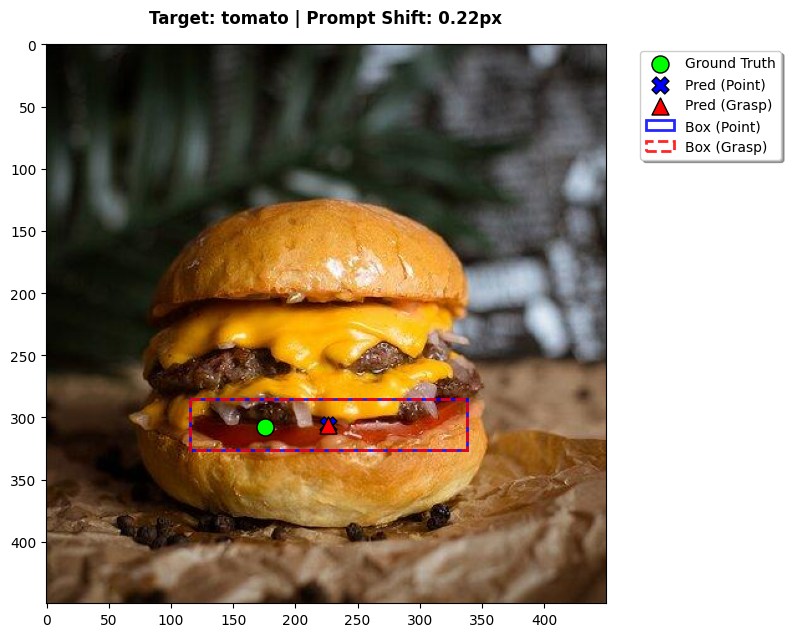

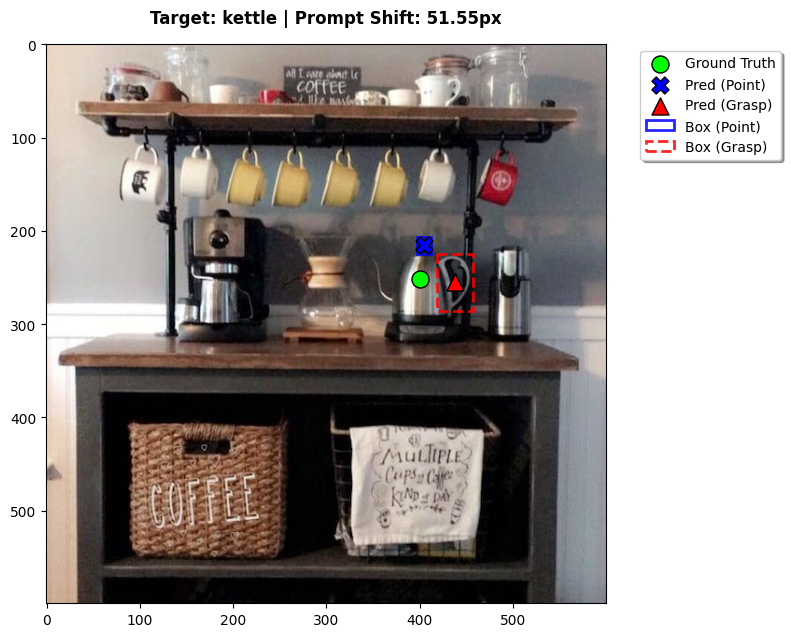

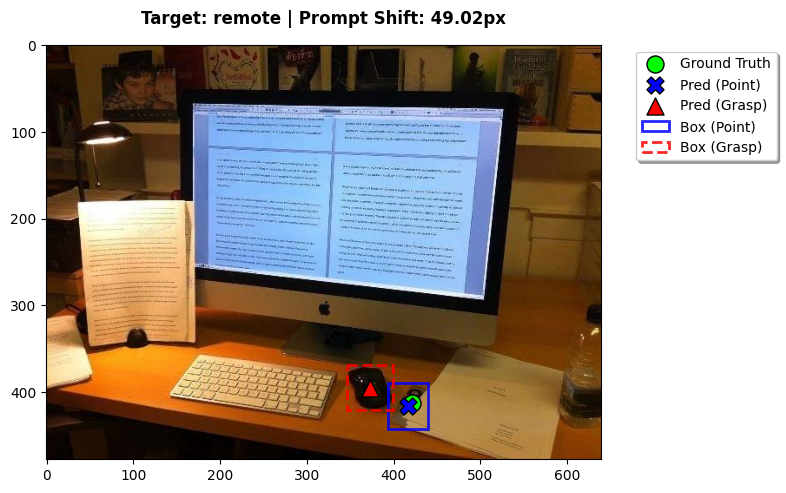

In [ ]:

# ============================================================================================
# Cell 9: Qualitative Visual Verification and Spatial Mapping
# ============================================================================================
# Stochastic sampling to observe if coordinate 'shifts' align with semantic
# object affordances (e.g., handles vs. centroids).
sample_size = min(3, len(results))
samples = random.sample(results, sample_size)

for row in samples:
    img = Image.open(row['image_path']).convert("RGB")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)

    # 1. Plot the Centroid Dots
    # Ground Truth:
    ax.scatter(row['gt_x'], row['gt_y'], c='lime', s=150,
               label='Ground Truth', edgecolors='black', linewidths=1, zorder=4)
    # Point Pred:
    ax.scatter(row['pred_x_point'], row['pred_y_point'], c='blue', marker='X', s=150,
               edgecolors='black', linewidths=1, label='Pred (Point)', zorder=5)
    # Grasp Pred:
    ax.scatter(row['pred_x_grasp'], row['pred_y_grasp'], c='red', marker='^', s=150,
               edgecolors='black', linewidths=1, label='Pred (Grasp)', zorder=6)

    # 2. Draw the Bounding Boxes
    box_p = row['pred_box_point']

    rect_point = patches.Rectangle((box_p[0], box_p[1]), box_p[2] - box_p[0], box_p[3] - box_p[1],
                                   linewidth=2, edgecolor='blue', facecolor='none', linestyle='-', alpha=0.85, label='Box (Point)', zorder=3)
    ax.add_patch(rect_point)

    box_g = row['pred_box_grasp']

    rect_grasp = patches.Rectangle((box_g[0], box_g[1]), box_g[2] - box_g[0], box_g[3] - box_g[1],
                                   linewidth=2, edgecolor='red', facecolor='none', linestyle='--', alpha=0.85, label='Box (Grasp)', zorder=4)
    ax.add_patch(rect_grasp)

    ax.set_title(f"Target: {row['label']} | Prompt Shift: {row['prompt_sensitivity']}px", pad=15, fontweight='bold')

    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', shadow=True)
    # plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:

# ============================================================================================
# Cell 10: Edge-Case Identification and Model Failure Characterization
# ============================================================================================
if len(results) > 0:
    df_analysis = pd.DataFrame(results)

    # Instances where pixel error exceeds the functionally acceptable radius for robotic manipulation.
    threshold_failures = df_analysis[df_analysis['success_rate'] == 0]

    print(f"\n{' FAILURE CHARACTERIZATION REPORT '.center(TOTAL_WIDTH, '=')}\n")
    print(f"[REPORT] Aggregate Threshold Failures (>50px error): {len(threshold_failures)} / {len(df_analysis)} samples")

    if not threshold_failures.empty:
        # Failure distribution analysis identifies systemic class-level bottlenecks.
        # Top 5 Systemic Class Bottlenecks:
        print("\n[ANALYSIS] Distribution of class-specific localization failures:")
        bottlenecks = threshold_failures['label'].value_counts().head(5)
        for label, count in bottlenecks.items():
            print(f"  -> {label.capitalize()}: {count} failures")

        # Top 10 Diagnostic Edge-Cases
        print("\n[LOG] Diagnostic review candidates (Highest Error First):")
        worst_performers = threshold_failures.sort_values(by='avg_pixel_error', ascending=False)

        for _, row in worst_performers.head(10).iterrows():
            img_name = os.path.basename(row['image_path'])
            print(f" - {img_name:<16} (Target: {row['label']:<10}): Avg Error {row['avg_pixel_error']:>7.2f}px | Prompt Shift: {row['prompt_sensitivity']:>6.2f}px")

    print(f"\n{CLI_SEP}\n")
else:
    print("[CRITICAL WARNING] No successful results to analyze.")


================================= FAILURE CHARACTERIZATION REPORT ==================================

[REPORT] Aggregate Threshold Failures (>50px error): 142 / 183 samples

[ANALYSIS] Distribution of class-specific localization failures:
  -> Apple: 4 failures
  -> Backpack: 4 failures
  -> Bag: 4 failures
  -> Calculator: 4 failures
  -> Fork: 4 failures

[LOG] Diagnostic review candidates (Highest Error First):
 - bag_9.jpg        (Target: bag       ): Avg Error 3068.71px | Prompt Shift: 1768.90px
 - cup_6.jpg        (Target: cup       ): Avg Error 2926.86px | Prompt Shift:   3.37px
 - pan_18.jpg       (Target: pan       ): Avg Error 1990.77px | Prompt Shift:   0.00px
 - pot_3.jpg        (Target: pot       ): Avg Error 1268.24px | Prompt Shift:   2.02px
 - tray_10.jpg      (Target: tray      ): Avg Error 1093.46px | Prompt Shift:   2.48px
 - toothbrush_9.jpg (Target: toothbrush): Avg Error 1049.91px | Prompt Shift: 1585.34px
 - charger_18.jpg   (Target: charger   ): Avg Error  993.

In [ ]:

# ============================================================================================
# Cell 11: Automated Technical Reporting Dependencies and Module Initialization
# ============================================================================================
!pip install -q reportlab

import os
import pandas as pd

# ReportLab Specific Imports
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph, SimpleDocTemplate, Spacer, Table, TableStyle, PageBreak

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.4 MB/s eta 0:00:00


In [ ]:

# ============================================================================================
# Cell 12: Document Synthesis (PDF)
# ============================================================================================
PDF_PATH = os.path.join(OUTPUT_DIR, "Florence2_Dual_Prompt_Report.pdf")

def generate_pdf(output_path, results_list):
    if not results_list:
        print("[WARNING] No data to generate PDF.")
        return

    df = pd.DataFrame(results_list)

    class CanvasPDF(canvas.Canvas):
        def __init__(self, *args, **kwargs):
            canvas.Canvas.__init__(self, *args, **kwargs)
            self._saved_page_states = []

        def showPage(self):
            self._saved_page_states.append(dict(self.__dict__))
            self._startPage()

        def save(self):
            num_pages = len(self._saved_page_states)
            for state in self._saved_page_states:
                self.__dict__.update(state)
                self.draw_page_number(num_pages)
                canvas.Canvas.showPage(self)
            canvas.Canvas.save(self)

        def draw_page_number(self, page_count):
            self.saveState()

            page_text = f"Page {self._pageNumber} of {page_count}"
            self.setFont("Helvetica", 9)
            self.setFillColor(colors.gray)
            self.drawRightString(letter[0] - 40, 30, page_text)

            self.restoreState()

    SUCCESS_THRESHOLD = 50
    df['success_point'] = (df['pixel_error_point'] <= SUCCESS_THRESHOLD).astype(int)
    df['success_grasp'] = (df['pixel_error_grasp'] <= SUCCESS_THRESHOLD).astype(int)

    df['dual_success'] = ((df['success_point'] == 1) & (df['success_grasp'] == 1)).astype(int)

    df['norm_err_point'] = df['normalized_pixel_error_point'] * 100
    df['norm_err_grasp'] = df['normalized_pixel_error_grasp'] * 100

    agg_df = df.groupby('label').agg(
        count=('label', 'count'),
        avg_point_err=('pixel_error_point', 'mean'),
        avg_grasp_err=('pixel_error_grasp', 'mean'),
        avg_norm_err_point=('norm_err_point', 'mean'),
        avg_norm_err_grasp=('norm_err_grasp', 'mean'),
        avg_shift=('prompt_sensitivity', 'mean'),
        success_point_rate=('success_point', lambda x: x.mean() * 100),
        success_grasp_rate=('success_grasp', lambda x: x.mean() * 100)
    ).reset_index().sort_values(by='avg_shift', ascending=False)

    # --- DOCUMENT SETUP ---
    doc = SimpleDocTemplate(output_path, pagesize=letter, rightMargin=40, leftMargin=40, topMargin=50, bottomMargin=60)
    styles = getSampleStyleSheet()

    title_style = ParagraphStyle('TitleStyle', parent=styles['Heading1'], fontName='Helvetica-Bold', fontSize=16, alignment=1, spaceAfter=15)
    h2_style = ParagraphStyle('H2Style', parent=styles['Heading2'], fontName='Helvetica-Bold', fontSize=12, spaceBefore=15, spaceAfter=5)
    normal_style = ParagraphStyle('NormalStyle', parent=styles['Normal'], fontName='Helvetica', fontSize=10, leading=16)
    legend_style = ParagraphStyle('LegendStyle', parent=styles['Normal'], fontName='Helvetica-Oblique', fontSize=9, textColor=colors.dimgrey, spaceAfter=10)

    oxford_blue = colors.HexColor('#1f497d')
    elements = []

    elements.append(Paragraph("Zero-Shot VLM Evaluation: Florence-2 Report", title_style))
    elements.append(Paragraph("<b>Research Lead:</b> Jannine G. D. MacGormain", normal_style))
    elements.append(Spacer(1, 15))

    elements.append(Paragraph("1. Standard Performance Metrics", h2_style))

    global_metrics = (
        f"<b>Total Evaluated Samples:</b> {len(df)} images<br/>"
        f"<b>Success Rate ('Point' Prompt):</b> {df['success_point'].mean() * 100:.1f}%<br/>"
        f"<b>Success Rate ('Grasp' Prompt):</b> {df['success_grasp'].mean() * 100:.1f}%<br/>"
        f"<b>Per-Prompt Error ('Point' Prompt):</b> {df['pixel_error_point'].mean():.2f} pixels<br/>"
        f"<b>Per-Prompt Error ('Grasp' Prompt):</b> {df['pixel_error_grasp'].mean():.2f} pixels<br/>"
        f"<b>Prompt Sensitivity:</b> {df['prompt_sensitivity'].mean():.2f} pixels<br/>"
        f"<b>Prompt Consistency:</b> {df['prompt_consistency'].mean():.4f}<br/>"
        f"<b>Dual-Prompt Success Rate (Both &lt;50px):</b> {df['dual_success'].mean() * 100:.2f}%"
    )
    elements.append(Paragraph(global_metrics, normal_style))
    elements.append(Spacer(1, 15))

    elements.append(Paragraph("2. Comparative Analysis: Per-Category Metrics", h2_style))

    table_1_legend = "<b>Legend:</b> <b>Pt</b> = 'Point to...' Prompt | <b>Gr</b> = 'Grasp...' Prompt | <b>Px Err</b> = Pixel Error | <b>Norm Err</b> = Normalized Error | <b>Shift</b> = Prompt Sensitivity | <b>Succ</b> = Success Rate (&lt;50px)"
    elements.append(Paragraph(table_1_legend, legend_style))

    agg_header = [["Category", "Samples", "Px Err (Pt)", "Px Err (Gr)", "Norm Err (Pt)", "Norm Err (Gr)", "Shift (px)", "Succ (Pt)", "Succ (Gr)"]]
    agg_body = []

    for idx, (_, row) in enumerate(agg_df.iterrows(), start=1):
        agg_body.append([
            row['label'].capitalize(), str(row['count']),
            f"{row['avg_point_err']:.1f}", f"{row['avg_grasp_err']:.1f}",
            f"{row['avg_norm_err_point']:.1f}%", f"{row['avg_norm_err_grasp']:.1f}%",
            f"{row['avg_shift']:.1f}", f"{row['success_point_rate']:.0f}%", f"{row['success_grasp_rate']:.0f}%"
        ])

    # agg_body.append(["TOTAL", str(len(df)), "", "", "", "", "", "", ""])

    agg_body.append([
        "AGGREGATE",
        str(len(df)),
        f"{df['pixel_error_point'].mean():.1f}",
        f"{df['pixel_error_grasp'].mean():.1f}",
        f"{df['norm_err_point'].mean():.1f}%",
        f"{df['norm_err_grasp'].mean():.1f}%",
        f"{df['prompt_sensitivity'].mean():.1f}",
        f"{df['success_point'].mean()*100:.1f}%",
        f"{df['success_grasp'].mean()*100:.1f}%"
        ])

    agg_table = Table(agg_header + agg_body, hAlign='CENTER', colWidths=[80, 45, 55, 55, 60, 60, 50, 55, 55], repeatRows=1)

    agg_table_style = [
        ('BACKGROUND', (0, 0), (-1, 0), oxford_blue),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('GRID', (0, 0), (-1, -2), 0.5, colors.grey),
        ('ALIGN', (0, 0), (-1, 0), 'CENTER'),
        ('ALIGN', (0, 1), (-1, -1), 'CENTER'),
        ('ALIGN', (0, 1), (0, -1), 'LEFT'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTNAME', (0, 1), (-1, -2), 'Helvetica'),
        ('FONTSIZE', (0, 0), (-1, -1), 8),

        ('FONTNAME', (0, -1), (-1, -1), 'Helvetica-Bold'),
        ('BACKGROUND', (0, -1), (-1, -1), colors.HexColor('#e6eef5')),
        ('BOX', (0, -1), (-1, -1), 2, oxford_blue),
        ('INNERGRID', (0, -1), (-1, -1), 0.5, colors.grey)
    ]

    for i in range(1, len(agg_df) + 1):
        bg_color = colors.whitesmoke if i % 2 != 0 else colors.lightgrey
        agg_table_style.append(('BACKGROUND', (0, i), (-1, i), bg_color))

    agg_table.setStyle(TableStyle(agg_table_style))
    elements.append(agg_table)

    elements.append(PageBreak())
    elements.append(Paragraph("3. Qualitative Analysis: Raw Data Pipeline", h2_style))

    table_2_legend = "<b>Legend:</b> <b>Size</b> = Image Dimensions (w,h) | <b>GT</b> = Ground Truth Coordinates | <b>Pt</b> = 'Point to...' Prediction | <b>Gr</b> = 'Grasp...' Prediction | <b>Px Err</b> = Pixel Error | <b>Shift</b> = Prompt Sensitivity"
    elements.append(Paragraph(table_2_legend, legend_style))

    raw_header = [["Image", "Size (w,h)", "GT (x,y)", "Pt (x,y)", "Gr (x,y)", "Px Err (Pt)", "Px Err (Gr)", "Shift"]]
    raw_body = []

    worst_performers = df.sort_values(by='prompt_sensitivity', ascending=False).head(40)

    for idx, (_, row) in enumerate(worst_performers.iterrows(), start=1):
        img_name = os.path.basename(row['image_path'])

        img_size = f"{int(row.get('width', 0))}x{int(row.get('height', 0))}"

        gt_coord = f"({int(row['gt_x'])}, {int(row['gt_y'])})"
        pt_coord = f"({int(row['pred_x_point'])}, {int(row['pred_y_point'])})"
        gr_coord = f"({int(row['pred_x_grasp'])}, {int(row['pred_y_grasp'])})"

        raw_body.append([
            img_name, img_size, gt_coord, pt_coord, gr_coord,
            f"{row['pixel_error_point']:.1f}", f"{row['pixel_error_grasp']:.1f}", f"{row['prompt_sensitivity']:.1f}"
        ])

    raw_table = Table(raw_header + raw_body, hAlign='CENTER', colWidths=[95, 60, 65, 65, 65, 50, 50, 45], repeatRows=1)

    raw_table_style = [
        ('BACKGROUND', (0, 0), (-1, 0), oxford_blue),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
        ('ALIGN', (0, 0), (-1, 0), 'CENTER'),
        ('ALIGN', (0, 1), (-1, -1), 'CENTER'),
        ('ALIGN', (0, 1), (0, -1), 'LEFT'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTNAME', (0, 1), (-1, -1), 'Helvetica'),
        ('FONTSIZE', (0, 0), (-1, -1), 8),
        ('BOTTOMPADDING', (0, 0), (-1, -1), 5),
        ('TOPPADDING', (0, 0), (-1, -1), 5)
    ]

    for i in range(1, len(worst_performers) + 1):
        bg_color = colors.whitesmoke if i % 2 != 0 else colors.lightgrey
        raw_table_style.append(('BACKGROUND', (0, i), (-1, i), bg_color))

    raw_table.setStyle(TableStyle(raw_table_style))
    elements.append(raw_table)

    doc.build(elements, canvasmaker=CanvasPDF)

generate_pdf(PDF_PATH, results)
print(f"✅ [STATUS] Technical PDF report synthesized successfully: {PDF_PATH}")

✅ [STATUS] Technical PDF report synthesized successfully: /content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_final_report/Florence2_Dual_Prompt_Report.pdf


In [ ]:

# ============================================================================================
# Cell 13: Aggregate JSON Outputs (Florence-2 Baseline)
# ============================================================================================
# Synchronizing Florence-2 results with CLIP/DINO comparative study architecture.

df_final = pd.DataFrame(results)

# test_final_per_image.json: Raw metric log for spatial parity verification.
with open(os.path.join(OUTPUT_DIR, "test_final_per_image.json"), "w") as f:
    json.dump(results, f, indent=4)

# test_final_per_category.json: Aggregated class-level error distribution.
with open(os.path.join(OUTPUT_DIR, "test_final_per_category.json"), "w") as f:
    json.dump(per_category_error, f, indent=4)

# test_final_summary.json: Standard performance metrics (Grounding Success & Error).
summary_payload = {
    "model_id": "Florence-2-large",
    "total_samples": len(results),
    "standard_metrics": {
        "mean_pixel_error_point": round(float(df_final['pixel_error_point'].mean()), 2),
        "mean_pixel_error_grasp": round(float(df_final['pixel_error_grasp'].mean()), 2),
        "mean_prompt_sensitivity": round(float(df_final['prompt_sensitivity'].mean()), 2),
        "overall_success_rate": round(float(df_final['success_rate'].mean()), 4)
    }
}
with open(os.path.join(OUTPUT_DIR, "test_final_summary.json"), "w") as f:
    json.dump(summary_payload, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "val_prompt_eval.json"), "w") as f:
    json.dump(results, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "val_prompt_summary.json"), "w") as f:
    json.dump(summary_payload["standard_metrics"], f, indent=4)

print(f"✅ [STATUS] Aggregate JSON Outputs successfully generated in: {OUTPUT_DIR}")

✅ [STATUS] Aggregate JSON Outputs successfully generated in: /content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_final_report


--------------------------------------------------------------------------------
[SUCCESS] High-resolution graphic exported to: /content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_final_report/florence2_data_visualization.png
--------------------------------------------------------------------------------









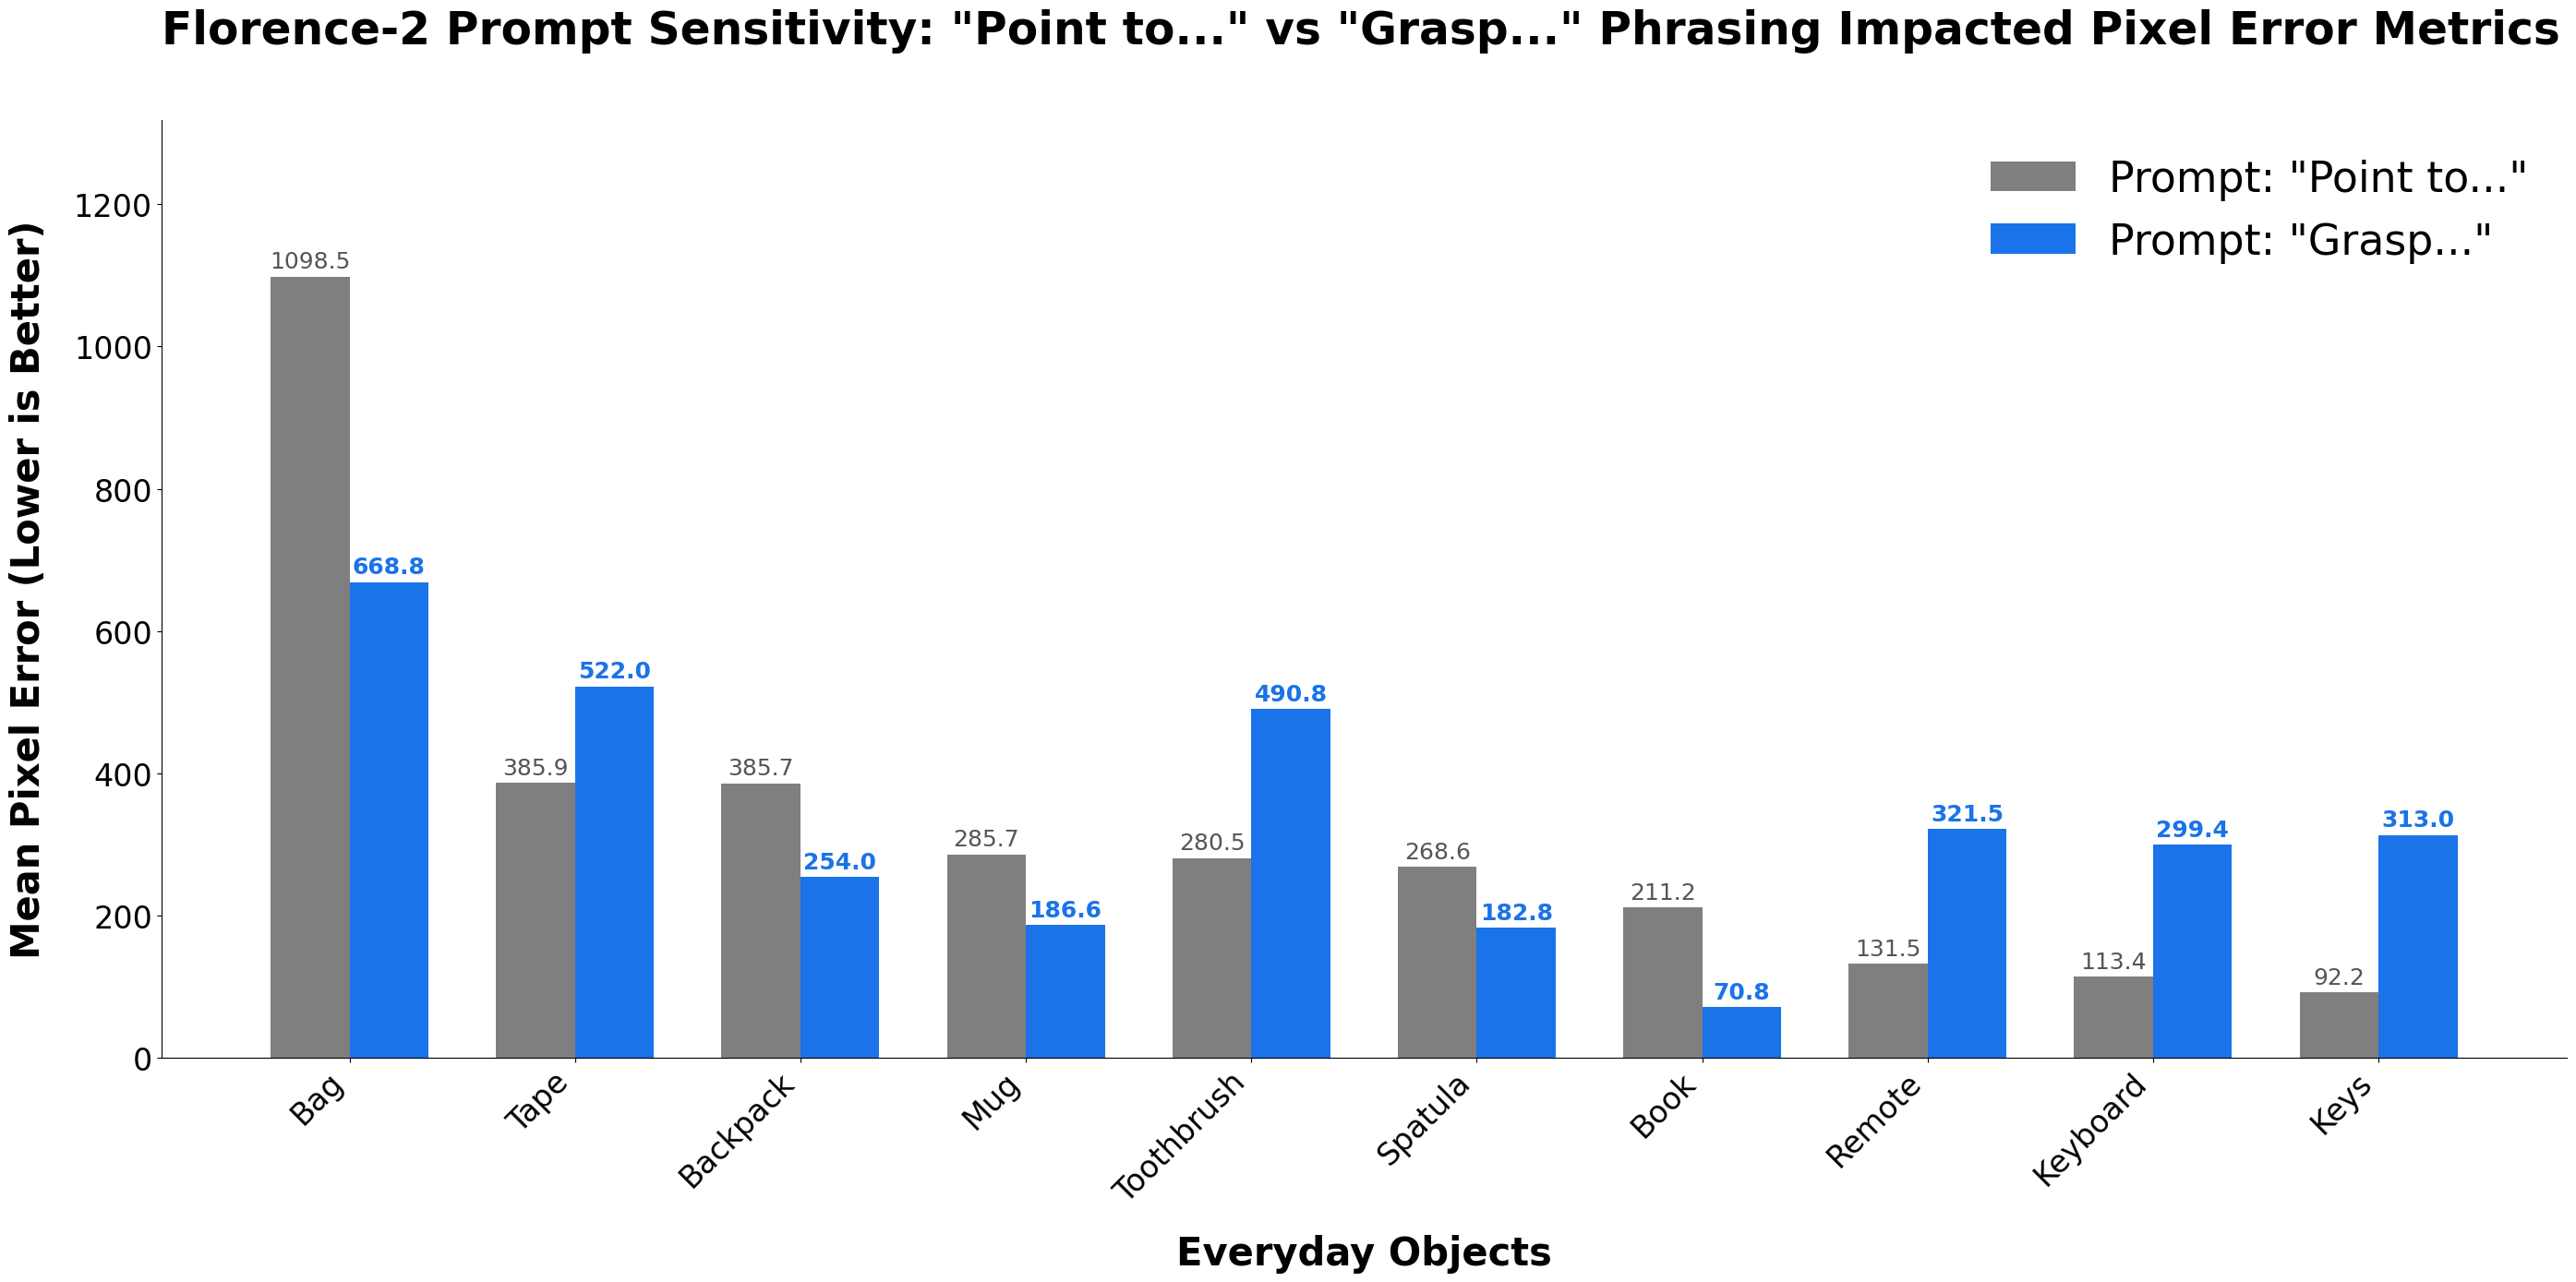

In [ ]:

# ============================================================================================
# Cell 14: Data Visualization
# ============================================================================================
# Command Line Interface separator
CLI_SEPARATOR = "-" * 80

category_summary = df_analysis.groupby('label').agg(
    avg_point=('pixel_error_point', 'mean'),
    avg_grasp=('pixel_error_grasp', 'mean')
).reset_index()

category_summary['diff'] = abs(category_summary['avg_point'] - category_summary['avg_grasp'])
top_10_variance = category_summary.sort_values(by='diff', ascending=False).head(10)

top_categories = top_10_variance.sort_values(by='avg_point', ascending=False)

labels = top_categories['label'].tolist()
point_errs = top_categories['avg_point'].tolist()
grasp_errs = top_categories['avg_grasp'].tolist()

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(28, 14))
rects1 = ax.bar(x - width/2, point_errs, width, label='Prompt: "Point to..."', color='#7F7F7F')
rects2 = ax.bar(x + width/2, grasp_errs, width, label='Prompt: "Grasp..."', color='#1A73E8')

headline_chart = ('Florence-2 Prompt Sensitivity: "Point to..." vs "Grasp..." Phrasing Impacted Pixel Error Metrics\n')

ax.set_title(headline_chart, fontsize=35, fontweight='bold', loc='left', pad=20)
ax.set_ylabel('Mean Pixel Error (Lower is Better)', fontsize=30, fontweight='bold', labelpad=20)
ax.set_xlabel('Everyday Objects', fontsize=30, fontweight='bold', labelpad=20)
ax.set_xticks(x)
ax.tick_params(axis='both', labelsize=24)
ax.set_xticklabels([label.capitalize() for label in labels], fontsize=24, rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=33)
ax.bar_label(rects1, padding=3, fmt='%.1f', color='#555555', fontsize=18)
ax.bar_label(rects2, padding=3, fmt='%.1f', color='#1A73E8', fontweight='bold', fontsize=18)
ax.set_ylim(0, max(point_errs) * 1.2)

plt.tight_layout()

print(CLI_SEPARATOR)
CHART_PATH = os.path.join(OUTPUT_DIR, "florence2_data_visualization.png")
plt.savefig(CHART_PATH, dpi=300, bbox_inches='tight')
print(f"[SUCCESS] High-resolution graphic exported to: {CHART_PATH}")
print(CLI_SEPARATOR)
print("\n\n\n\n\n\n")
plt.show()

[SUCCESS] Architectural diagram exported to: /content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_final_report/florence2_project_architecture.png



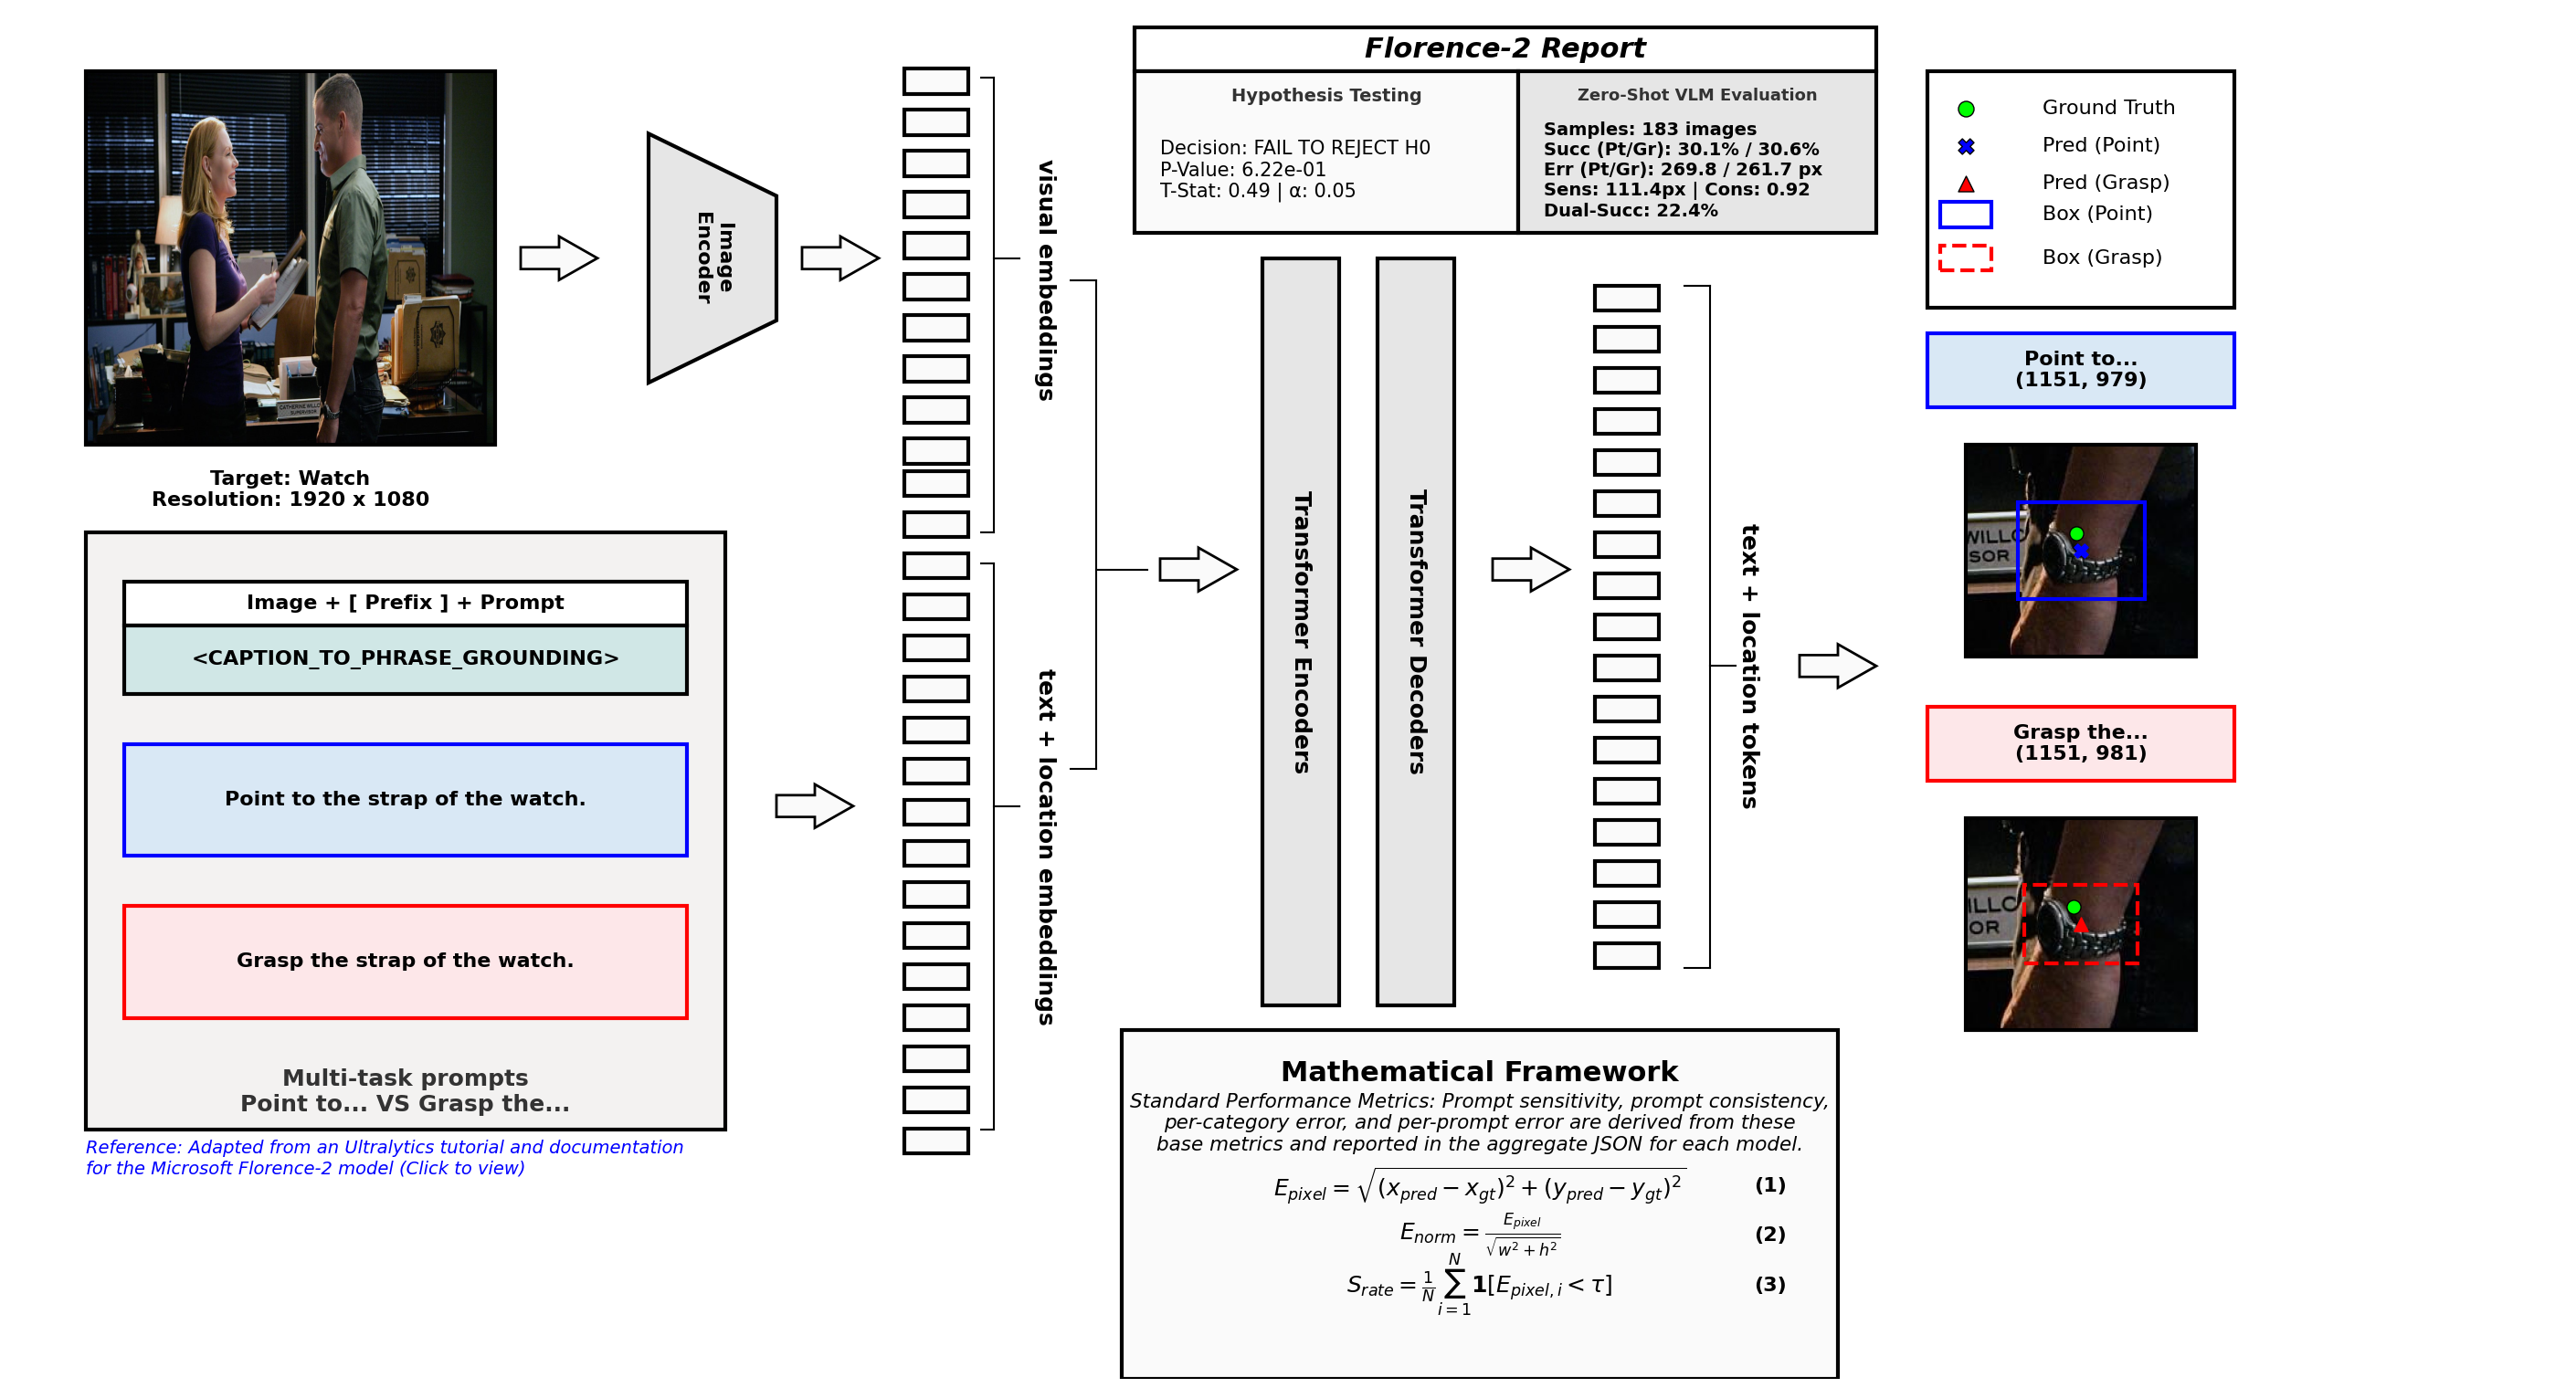

In [ ]:

# ============================================================================================
# Cell 15: Florence-2 Architectural
# ============================================================================================
def generate_architectural_report(hypothesis_dict, results_list, output_path):
    if not results_list:
        print("[CRITICAL ERROR] No results found to plot. Aborting...")
        return
    summary = hypothesis_dict["evaluation_summary"]
    stats = hypothesis_dict["inferential_statistics"]

    valid_samples = [r for r in results_list if r['success_rate'] == 1]
    sample = random.choice(valid_samples) if valid_samples else results_list[0]

    fig = plt.figure(figsize=(28, 15), facecolor='white')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 100); ax.set_ylim(-10, 100); ax.axis('off')

    def draw_arrow(x, y, w=3, h=3.5):
        pts = [[x, y-h/4], [x+w/2, y-h/4], [x+w/2, y-h/2], [x+w, y], [x+w/2, y+h/2], [x+w/2, y+h/4], [x, y+h/4]]
        ax.add_patch(patches.Polygon(pts, closed=True, facecolor='#fafafa', edgecolor='black', lw=2))

    # ============================================================================================
    # Left Column: Actual Image & Prompts
    # ============================================================================================
    try:
        input_img = Image.open(sample['image_path']).convert("RGB")
        ax.imshow(input_img, extent=[3, 19, 65, 95], aspect='auto', zorder=1)
        ax.add_patch(patches.Rectangle((3, 65), 16, 30, fill=False, edgecolor='black', lw=3, zorder=3))
        ax.text(11, 63, f"Target: {sample['label'].capitalize()}\nResolution: {sample['width']} x {sample['height']}",
                ha='center', va='top', fontsize=16, fontweight='bold', color='black')
    except Exception as e:
        print(f"[WARNING] Could not load image for {sample['label']}: {e}")

    ax.add_patch(patches.Rectangle((3, 10), 25, 48, facecolor='#F3F2F1', edgecolor='black', lw=3))

    ax.add_patch(patches.Rectangle((4.5, 50.5), 22, 3.5, facecolor='white', edgecolor='black', lw=3))
    ax.text(15.5, 52.25, "Image + [ Prefix ] + Prompt", fontsize=16, fontweight='bold', ha='center', va='center', color='black')

    ax.add_patch(patches.Rectangle((4.5, 45), 22, 5.5, facecolor='#D0E7E6', edgecolor='black', lw=3))

    ax.text(15.5, 47.75, "<CAPTION_TO_PHRASE_GROUNDING>", fontsize=16, fontweight='bold', ha='center', va='center')

    ax.add_patch(patches.Rectangle((4.5, 32), 22, 9, facecolor='#D9E8F5', edgecolor='blue', lw=3))
    ax.text(15.5, 36.5, sample['prompt_1'], fontsize=16, fontweight='bold', ha='center', va='center')

    ax.add_patch(patches.Rectangle((4.5, 19), 22, 9, facecolor='#FDE7E9', edgecolor='red', lw=3))
    ax.text(15.5, 23.5, sample['prompt_2'], fontsize=16, fontweight='bold', ha='center', va='center')

    ax.text(15.5, 13.0, "Multi-task prompts\nPoint to... VS Grasp the...", fontsize=18, ha='center', va='center', fontweight='bold', color='#333333')

    # ============================================================================================
    # Citation
    # ============================================================================================
    tutorial_url = "https://colab.research.google.com/github/ultralytics/notebooks/blob/main/notebooks/how-to-use-florence-2-for-object-detection-image-captioning-ocr-and-segmentation.ipynb#scrollTo=4v_Bmj1rte4o$0"

    ax.annotate("Reference: Adapted from an Ultralytics tutorial and documentation\nfor the Microsoft Florence-2 model (Click to view)",
                xy=(3, 6.5),
                xycoords='data',
                url=tutorial_url,
                fontsize=14,
                color='blue',
                style='italic',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.5))

    # ============================================================================================
    # Middle Column: Encoder, Embeddings, Transformers, Tokens
    # ============================================================================================
    # 1. Image Encoder Block
    draw_arrow(20, 80); draw_arrow(31, 80); draw_arrow(30, 36)
    ax.add_patch(patches.Polygon([[25, 70], [25, 90], [30, 85], [30, 75]], facecolor='#E6E6E6', edgecolor='black', lw=3))
    ax.text(27.5, 80, "Image\nEncoder", rotation=270, fontsize=16, fontweight='bold', ha='center', va='center')

    # 2. Embedding Token Stacks (Width: 2.5, Height: 2.0, Spacing: 3.3)
    for i in range(10): ax.add_patch(patches.Rectangle((35, 63.5 + (i*3.3)), 2.5, 2.0, facecolor='#FAFAFA', edgecolor='black', lw=3)) # Visual
    for i in range(17): ax.add_patch(patches.Rectangle((35, 8.1 + (i*3.3)), 2.5, 2.0, facecolor='#FAFAFA', edgecolor='black', lw=3))  # Text

    # 3. Visual Embeddings Bracket & Routing (Top)
    ax.plot([38.5, 38.5], [58, 94.5], color='black', lw=1.5)
    ax.plot([38.0, 38.5], [94.5, 94.5], color='black', lw=1.5)
    ax.plot([38.0, 38.5], [58, 58], color='black', lw=1.5)
    ax.plot([38.5, 39.5], [80, 80], color='black', lw=1.5)
    ax.text(40.5, 78.25, "visual embeddings", rotation=270, ha='center', va='center', fontsize=18, fontweight='bold')

    # 4. Text + Location Embeddings Bracket & Routing (Bottom)
    ax.plot([38.5, 38.5], [10, 55.5], color='black', lw=1.5)
    ax.plot([38.0, 38.5], [55.5, 55.5], color='black', lw=1.5)
    ax.plot([38.0, 38.5], [10, 10], color='black', lw=1.5)
    ax.plot([38.5, 39.5], [36, 36], color='black', lw=1.5)
    ax.text(40.5, 32.75, "text + location embeddings", rotation=270, ha='center', va='center', fontsize=18, fontweight='bold')

    # 5. Central Data Spine (Routing to Transformers)
    ax.plot([42.5, 42.5], [39, 78.25], color='black', lw=1.5)
    ax.plot([41.5, 42.5], [78.25, 78.25], color='black', lw=1.5)
    ax.plot([41.5, 42.5], [39, 39], color='black', lw=1.5)
    ax.plot([42.5, 44.5], [55, 55], color='black', lw=1.5)
    draw_arrow(45, 55)

    # 6. Transformer Blocks
    ax.add_patch(patches.Rectangle((49, 20), 3, 60, facecolor='#E6E6E6', edgecolor='black', lw=3))
    ax.text(50.5, 50, "Transformer Encoders", rotation=270, fontsize=18, fontweight='bold', ha='center', va='center')
    ax.add_patch(patches.Rectangle((53.5, 20), 3, 60, facecolor='#E6E6E6', edgecolor='black', lw=3))
    ax.text(55, 50, "Transformer Decoders", rotation=270, fontsize=18, fontweight='bold', ha='center', va='center')
    draw_arrow(58, 55)

    # 7. Output Token Stack & Bracket
    for i in range(17): ax.add_patch(patches.Rectangle((62, 23 + (i*3.3)), 2.5, 2.0, facecolor='#FAFAFA', edgecolor='black', lw=3))

    ax.plot([66.5, 66.5], [23, 77.8], color='black', lw=1.5)
    ax.plot([65.5, 66.5], [77.8, 77.8], color='black', lw=1.5)
    ax.plot([65.5, 66.5], [23, 23], color='black', lw=1.5)
    ax.plot([66.5, 67.5], [47.25, 47.25], color='black', lw=1.5)

    ax.text(68, 47.25, "text + location tokens", rotation=270, ha='center', va='center', fontsize=18, fontweight='bold')
    draw_arrow(70, 47.25)

    # ============================================================================================
    # Top Dashboard
    # ============================================================================================
    ax.add_patch(patches.Rectangle((44, 95), 29, 3.5, facecolor='white', edgecolor='black', lw=3))
    ax.text(58.5, 96.75, "Florence-2 Report", ha='center', va='center', fontsize=22, fontweight='bold', style='italic')
    ax.add_patch(patches.Rectangle((44, 82), 15, 13, facecolor='#FAFAFA', edgecolor='black', lw=3))
    ax.text(51.5, 93, "Hypothesis Testing", ha='center', va='center', fontsize=14, color='#333', fontweight='bold')
    hyp_text = f"Decision: {stats['decision']}\nP-Value: {stats['p_value']:.2e}\nT-Stat: {stats['t_statistic']:.2f} | α: {stats['alpha_level']}"
    ax.text(45, 87, hyp_text, ha='left', va='center', fontsize=15, color='black')
    ax.add_patch(patches.Rectangle((59, 82), 14, 13, facecolor='#E6E6E6', edgecolor='black', lw=3))
    ax.text(66, 93, "Zero-Shot VLM Evaluation", ha='center', va='center', fontsize=13, color='#333', fontweight='bold')

    total_samples = len(results_list)
    succ_point = sum(1 for r in results_list if r['pixel_error_point'] < 50) / total_samples * 100
    succ_grasp = sum(1 for r in results_list if r['pixel_error_grasp'] < 50) / total_samples * 100
    err_point = sum(r['pixel_error_point'] for r in results_list) / total_samples
    err_grasp = sum(r['pixel_error_grasp'] for r in results_list) / total_samples
    mean_shift = sum(r['prompt_sensitivity'] for r in results_list) / total_samples
    mean_cons = sum(r['prompt_consistency'] for r in results_list) / total_samples
    dual_succ = sum(r['success_rate'] for r in results_list) / total_samples * 100
    summary_data = f"Samples: {total_samples} images \nSucc (Pt/Gr): {succ_point:.1f}% / {succ_grasp:.1f}%\nErr (Pt/Gr): {err_point:.1f} / {err_grasp:.1f} px\nSens: {mean_shift:.1f}px | Cons: {mean_cons:.2f}\nDual-Succ: {dual_succ:.1f}%"
    ax.text(60, 87, summary_data, ha='left', va='center', fontsize=14, fontweight='bold', color='black')

    # ============================================================================================
    # Legend Box
    # ============================================================================================
    ax.add_patch(patches.Rectangle((75, 76), 12, 19, facecolor='white', edgecolor='black', lw=3))
    lx, ly = 76.5, 92

    # Plotting Markers
    ax.scatter(lx, ly, c='lime', s=150, edgecolors='black', lw=1)
    ax.text(lx+3, ly, "Ground Truth", va='center', fontsize=16)

    ax.scatter(lx, ly-3, c='blue', marker='X', s=150, edgecolors='black', lw=1)
    ax.text(lx+3, ly-3, "Pred (Point)", va='center', fontsize=16)

    ax.scatter(lx, ly-6, c='red', marker='^', s=150, edgecolors='black', lw=1)
    ax.text(lx+3, ly-6, "Pred (Grasp)", va='center', fontsize=16)

    # Plotting Boxes
    ax.add_patch(patches.Rectangle((lx-1, ly-9.5), 2, 2, fill=False, edgecolor='blue', lw=3))
    ax.text(lx+3, ly-8.5, "Box (Point)", va='center', fontsize=16)

    ax.add_patch(patches.Rectangle((lx-1, ly-13), 2, 2, fill=False, edgecolor='red', lw=3, linestyle='--'))
    ax.text(lx+3, ly-12, "Box (Grasp)", va='center', fontsize=16)

    # ============================================================================================
    # Far Right: Output Actions & Crops
    # ============================================================================================
    ax.add_patch(patches.Rectangle((75, 68), 12, 6, facecolor='#D9E8F5', edgecolor='blue', lw=3))
    ax.text(81, 71, f"Point to...\n({int(sample['pred_x_point'])}, {int(sample['pred_y_point'])})", ha='center', va='center', fontsize=16, fontweight='bold', color='black')

    bx1 = sample['pred_box_point']
    crop1 = input_img.crop((max(0, bx1[0]-50), max(0, bx1[1]-50), min(input_img.width, bx1[2]+50), min(input_img.height, bx1[3]+50)))
    ax.imshow(crop1, extent=[76.5, 85.5, 48, 65], aspect='auto', zorder=1)
    ax.add_patch(patches.Rectangle((76.5, 48), 9, 17, fill=False, edgecolor='black', lw=3, zorder=2))
    s1x, s1y = 9 / crop1.width, 17 / crop1.height

    ax.scatter(76.5 + (sample['gt_x'] - max(0, bx1[0]-50))*s1x, 48 + (sample['gt_y'] - max(0, bx1[1]-50))*s1y, c='lime', s=120, edgecolors='black', zorder=10)
    ax.scatter(76.5 + (sample['pred_x_point'] - max(0, bx1[0]-50))*s1x, 48 + (sample['pred_y_point'] - max(0, bx1[1]-50))*s1y, c='blue', marker='X', s=120, zorder=11)

    bx_w1, bx_h1 = (bx1[2]-bx1[0])*s1x, (bx1[3]-bx1[1])*s1y
    ax.add_patch(patches.Rectangle((76.5 + (bx1[0]-max(0, bx1[0]-50))*s1x, 48 + (bx1[1]-max(0, bx1[1]-50))*s1y), bx_w1, bx_h1, fill=False, edgecolor='blue', lw=3, zorder=9))

    ax.add_patch(patches.Rectangle((75, 38), 12, 6, facecolor='#FDE7E9', edgecolor='red', lw=3))
    ax.text(81, 41, f"Grasp the...\n({int(sample['pred_x_grasp'])}, {int(sample['pred_y_grasp'])})", ha='center', va='center', fontsize=16, fontweight='bold', color='black')

    bx2 = sample['pred_box_grasp']
    crop2 = input_img.crop((max(0, bx2[0]-50), max(0, bx2[1]-50), min(input_img.width, bx2[2]+50), min(input_img.height, bx2[3]+50)))
    ax.imshow(crop2, extent=[76.5, 85.5, 18, 35], aspect='auto', zorder=1)
    ax.add_patch(patches.Rectangle((76.5, 18), 9, 17, fill=False, edgecolor='black', lw=3, zorder=2))
    s2x, s2y = 9 / crop2.width, 17 / crop2.height

    ax.scatter(76.5 + (sample['gt_x'] - max(0, bx2[0]-50))*s2x, 18 + (sample['gt_y'] - max(0, bx2[1]-50))*s2y, c='lime', s=120, edgecolors='black', zorder=10)
    ax.scatter(76.5 + (sample['pred_x_grasp'] - max(0, bx2[0]-50))*s2x, 18 + (sample['pred_y_grasp'] - max(0, bx2[1]-50))*s2y, c='red', marker='^', s=120, zorder=9)

    bx_w2, bx_h2 = (bx2[2]-bx2[0])*s2x, (bx2[3]-bx2[1])*s2y
    ax.add_patch(patches.Rectangle((76.5 + (bx2[0]-max(0, bx2[0]-50))*s2x, 18 + (bx2[1]-max(0, bx2[1]-50))*s2y), bx_w2, bx_h2, fill=False, edgecolor='red', lw=3, linestyle='--', zorder=8))

    # ============================================================================================
    # Bottom: Mathematical Framework
    # ============================================================================================
    ax.add_patch(patches.Rectangle((43.5, -10), 28, 28, facecolor='#fafafa', edgecolor='black', lw=3))

    ax.text(57.5, 14.5, "Mathematical Framework", ha='center', va='center', fontsize=22, fontweight='bold')

    metric_desc = ("Standard Performance Metrics: Prompt sensitivity, prompt consistency,\n"
                   "per-category error, and per-prompt error are derived from these\n"
                   "base metrics and reported in the aggregate JSON for each model.")
    ax.text(57.5, 10.5, metric_desc, ha='center', va='center', fontsize=15.5, style='italic')

    ax.text(57.5, 5.5, r"$E_{pixel} = \sqrt{(x_{pred} - x_{gt})^2 + (y_{pred} - y_{gt})^2}$", ha='center', va='center', fontsize=18)
    ax.text(69.5, 5.5, "(1)", ha='right', va='center', fontsize=16, fontweight='bold')

    ax.text(57.5, 1.5, r"$E_{norm} = \frac{E_{pixel}}{\sqrt{w^2 + h^2}}$", ha='center', va='center', fontsize=18)
    ax.text(69.5, 1.5, "(2)", ha='right', va='center', fontsize=16, fontweight='bold')

    ax.text(57.5, -2.5, r"$S_{rate} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}[E_{pixel, i} < \tau]$", ha='center', va='center', fontsize=18)
    ax.text(69.5, -2.5, "(3)", ha='right', va='center', fontsize=16, fontweight='bold')

    # ============================================================================================
    # Export As High-Resolution PNG and PDF
    # ============================================================================================
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[SUCCESS] Architectural diagram exported to: {output_path}\n")
    plt.savefig(output_path.replace(".png", ".pdf"), bbox_inches='tight')

    plt.show()

ARCH_DIAGRAM_PATH = os.path.join(OUTPUT_DIR, "florence2_project_architecture.png")
generate_architectural_report(hypothesis_data, results, ARCH_DIAGRAM_PATH)



---

## **13. Appendix: AI/ML Program Alignment & Florence-2 Extended Capabilities**


### AI/ML Curriculum Alignment

| Curriculum Courses | Core Concepts & Project Alignment |
| --- | --- |
| **ENGR 510** | **Foundation & Probabilistic Modeling:** Provides the theoretical grounding for the project. It integrates Maximum Likelihood Estimation (MLE), Hypothesis Testing (utilized for our prompt sensitivity analysis), and the underlying mathematical basis of SGD and ADAM optimizers. |
| **ENGR 515** | **Data-Driven Optimization:** Focuses on objective minimization strategies and the practical application of SGD and ADAM optimizers. This framework is essential for understanding how the foundational weights (FLD-5B weights) of our evaluated models were established. |
| **ENGR 520** | **Architecture & Data Design:** Covers neural network Architecture Design and the formulation of Loss functions. It also explores the principles of Collecting and Curating Training Data, which we applied directly to our use of the PixMo-Points dataset. |
| **AI/ML Program** | **Theory into Practice:** Represents the fundamental learning goal of the program. Students synthesize theoretical coursework from the 510, 515, and 520 series into functional, applied engineering solutions through the ENGR 521: Project. |
| **ENGR 521: Project** | **Computer Vision (CV) & VLMs:** The project application domain of the program. It explicitly focuses on the deployment, benchmarking, and spatial evaluation of Vision-Language Models. |
| **Florence-2 Model** | **Project Implementation:** The specific VLM architecture investigated, characterized by its zero-shot inference capabilities - the ability to localize objects without prior training on our specific dataset. Additionally, it operates on a unified Seq2Seq vision framework and relies on massive FLD-5B pretraining weights. |


![Curriculum Alignment](https://raw.githubusercontent.com/priyagautham28/grasp-point-prediction/main/outputs/florence2_final_report/curriculum_alignment.png)



### Florence-2 Extended Capabilities

| Florence-2 Vision Task Prefixes | Description & Functional Details |
| --- | --- |
| `<OD>` | **Object Detection:** Detects, identifies, and recognizes various objects within images or video frames, generating bounding boxes for spatial localization [13]. |
| `<CAPTION>` | **Standard Captioning:** Generates captions for input image content without requiring user-defined text prompts. By default, the Florence-2 Caption feature provides three levels of granularity: `CAPTION`, `DETAILED_CAPTION`, and `MORE_DETAILED_CAPTION`. `CAPTION` is generally the most accurate, while the detailed variants prioritize broader context over strict precision [13]. |
| `<DETAILED_CAPTION>` | **Detailed Captioning:** Yields an expanded description of the visual scene, prioritizing broader contextual elements over strict localization [13]. |
| `<MORE_DETAILED_CAPTION>` | **Comprehensive Captioning:** Constructs an extensive narrative detailing the complex composition and subtle elements present in the input [13]. |
| `<DENSE_REGION_CAPTION>` | **Dense Region Captioning:** Generates precise, localized text descriptions for individual regions or distinct items within the visual field [13]. |
| `<REGION_PROPOSAL>` | **Region Proposal:** Highlights spatial zones with a high probability of containing distinctive features. This serves as an initial filtration step to suggest potential object locations before final classification and bounding box refinement [13]. |
| **`<CAPTION_TO_PHRASE_GROUNDING>`** | **Phrase Grounding (Project Core):** Utilizes a custom natural language prompt to generate precise bounding boxes tailored to specific requirements. This is the exclusive prefix utilized in our project. Specifically, it is sufficient to move beyond coarse bounding-box localization toward predicting the precise (x, y) pixel coordinates required for safe robotic interaction. This serves as the primary mechanism in our pipeline for targeting language-guided interaction points [13]. |
| `<REFERRING_EXPRESSION_SEGMENTATION>` | **Expression Segmentation:** Creates granular, pixel-level masks that correspond directly to user-defined linguistic descriptions [13]. |
| `<REGION_TO_SEGMENTATION>` | **Region-Based Segmentation:** Computes segmentation masks bounded by explicit, normalized spatial coordinates provided by the user [13]. |
| `<OPEN_VOCABULARY_DETECTION>` | **Open Vocabulary Detection:** Enables the model to detect both objects and text (OCR) without being limited to predefined training categories. This makes it adaptable for real-world applications like retail, navigation, and document analysis [13]. |
| `<OCR_WITH_REGION>` | **Optical Character Recognition:** Extracts alphanumeric characters from visual inputs while simultaneously mapping them to their precise spatial coordinates [13]. |


### **Python Code**

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
[SUCCESS] Curriculum Alignment diagram exported to: /content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_final_report/curriculum_alignment.png



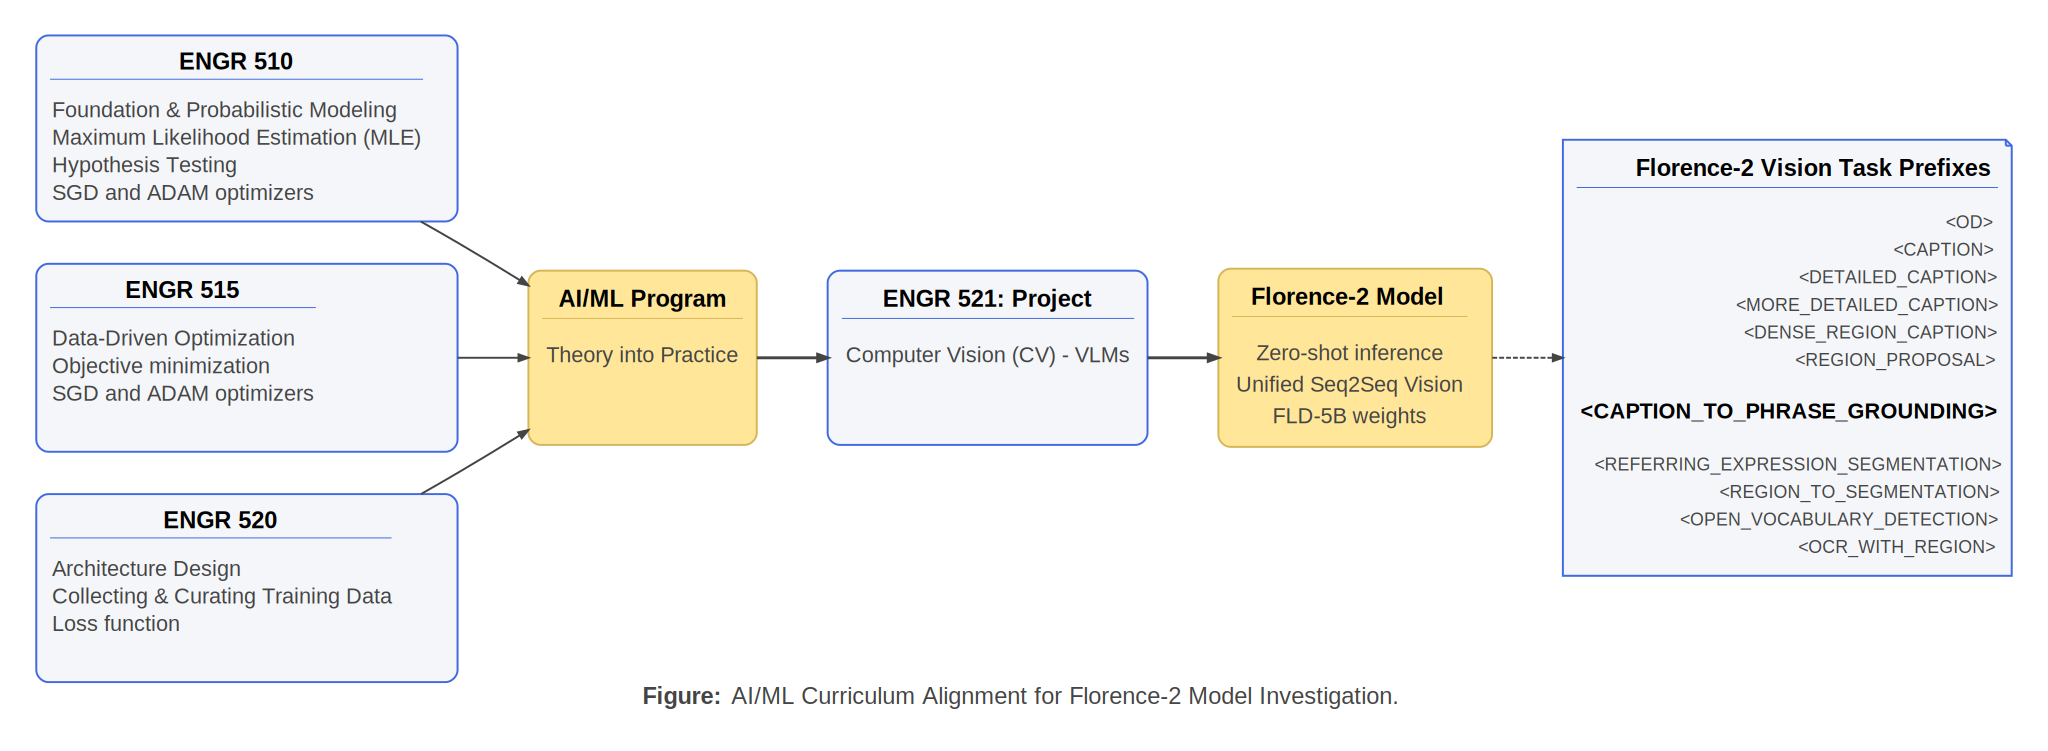

In [ ]:
!apt-get update -qq
!pip install -q graphviz

from graphviz import Digraph
from google.colab import drive
from IPython.display import display
import os

dot = Digraph(name="Curriculum Alignment", format='png')

dot.attr(rankdir='LR', splines='spline', nodesep='0.6', ranksep='1.0', pad='0.5')

dot.attr(label='<<B><FONT POINT-SIZE="24">Figure: </FONT></B><FONT POINT-SIZE="24"> AI/ML Curriculum Alignment for Florence-2 Model Investigation.</FONT>>',
         labelloc='b', labeljust='c', fontname='Helvetica', fontsize='24', fontcolor='#444444')

dot.attr('node',
         shape='box',
         style='rounded,filled',
         fillcolor='#f4f6f9',
         color='#4169e1',
         penwidth='2',
         fontname='Helvetica',
         fixedsize='false',
         margin='0.2')

node_510 = '''<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="2" WIDTH="400">
  <TR><TD ALIGN="CENTER"><B><FONT POINT-SIZE="24">ENGR 510</FONT></B></TD></TR>
  <HR/>
  <TR><TD height="10"> </TD></TR>
  <TR><TD ALIGN="LEFT"><FONT POINT-SIZE="22" COLOR="#444444">Foundation &amp; Probabilistic Modeling</FONT></TD></TR>
  <TR><TD ALIGN="LEFT"><FONT POINT-SIZE="22" COLOR="#444444">Maximum Likelihood Estimation (MLE)</FONT></TD></TR>
  <TR><TD ALIGN="LEFT"><FONT POINT-SIZE="22" COLOR="#444444">Hypothesis Testing</FONT></TD></TR>
  <TR><TD ALIGN="LEFT"><FONT POINT-SIZE="22" COLOR="#444444">SGD and ADAM optimizers</FONT></TD></TR>
</TABLE>>'''
dot.node('ENGR510', node_510)

node_515 = '''<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="2" WIDTH="400">
  <TR><TD ALIGN="CENTER"><B><FONT POINT-SIZE="24">ENGR 515</FONT></B></TD></TR>
  <HR/>
  <TR><TD height="10"> </TD></TR>
  <TR><TD ALIGN="LEFT"><FONT POINT-SIZE="22" COLOR="#444444">Data-Driven Optimization</FONT></TD></TR>
  <TR><TD ALIGN="LEFT"><FONT POINT-SIZE="22" COLOR="#444444">Objective minimization</FONT></TD></TR>
  <TR><TD ALIGN="LEFT"><FONT POINT-SIZE="22" COLOR="#444444">SGD and ADAM optimizers</FONT></TD></TR>
  <TR><TD height="30"> </TD></TR>
</TABLE>>'''
dot.node('ENGR515', node_515)

node_520 = '''<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="2" WIDTH="400">
  <TR><TD ALIGN="CENTER"><B><FONT POINT-SIZE="24">ENGR 520</FONT></B></TD></TR>
  <HR/>
  <TR><TD height="10"> </TD></TR>
  <TR><TD ALIGN="LEFT"><FONT POINT-SIZE="22" COLOR="#444444">Architecture Design</FONT></TD></TR>
  <TR><TD ALIGN="LEFT"><FONT POINT-SIZE="22" COLOR="#444444">Collecting &amp; Curating Training Data</FONT></TD></TR>
  <TR><TD ALIGN="LEFT"><FONT POINT-SIZE="22" COLOR="#444444">Loss function</FONT></TD></TR>
  <TR><TD height="30"> </TD></TR>
</TABLE>>'''
dot.node('ENGR520', node_520)

with dot.subgraph(name='cluster_project') as c:
    c.attr(style='invis')

    node_prog = '''<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="4" WIDTH="200">
      <TR><TD ALIGN="CENTER"><B><FONT POINT-SIZE="24">AI/ML Program</FONT></B></TD></TR>
      <HR/>
      <TR><TD height="10"> </TD></TR>
      <TR><TD ALIGN="CENTER"><FONT POINT-SIZE="22" COLOR="#444444">Theory into Practice</FONT></TD></TR>
      <TR><TD height="30"> </TD></TR>
      <TR><TD height="30"> </TD></TR>
    </TABLE>>'''
    c.node('PROG', node_prog, fillcolor='#ffe699', color='#d6b656')

    node_proj = '''<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="4" WIDTH="250">
      <TR><TD ALIGN="CENTER"><B><FONT POINT-SIZE="24">ENGR 521: Project</FONT></B></TD></TR>
      <HR/>
      <TR><TD height="10"> </TD></TR>
      <TR><TD ALIGN="CENTER"><FONT POINT-SIZE="22" COLOR="#444444">Computer Vision (CV) - VLMs</FONT></TD></TR>
      <TR><TD height="30"> </TD></TR>
      <TR><TD height="30"> </TD></TR>
    </TABLE>>'''
    c.node('PROJ', node_proj)

    node_model = '''<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="4" WIDTH="250">
      <TR><TD ALIGN="CENTER"><B><FONT POINT-SIZE="24">Florence-2 Model</FONT></B></TD></TR>
      <HR/>
      <TR><TD height="10"> </TD></TR>
      <TR><TD ALIGN="CENTER"><FONT POINT-SIZE="22" COLOR="#444444">Zero-shot inference</FONT></TD></TR>
      <TR><TD ALIGN="CENTER"><FONT POINT-SIZE="22" COLOR="#444444">Unified Seq2Seq Vision</FONT></TD></TR>
      <TR><TD ALIGN="CENTER"><FONT POINT-SIZE="22" COLOR="#444444">FLD-5B weights</FONT></TD></TR>
    </TABLE>>'''
    c.node('MODEL', node_model, fillcolor='#ffe699', color='#d6b656')

node_pref = '''<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="4">
  <TR><TD ALIGN="RIGHT"><B><FONT POINT-SIZE="24">Florence-2 Vision Task Prefixes</FONT></B></TD></TR>
  <HR/>
  <TR><TD height="10"> </TD></TR>
  <TR><TD ALIGN="RIGHT"><FONT POINT-SIZE="18" COLOR="#444444">&lt;OD&gt;</FONT></TD></TR>
  <TR><TD ALIGN="RIGHT"><FONT POINT-SIZE="18" COLOR="#444444">&lt;CAPTION&gt;</FONT></TD></TR>
  <TR><TD ALIGN="RIGHT"><FONT POINT-SIZE="18" COLOR="#444444">&lt;DETAILED_CAPTION&gt;</FONT></TD></TR>
  <TR><TD ALIGN="RIGHT"><FONT POINT-SIZE="18" COLOR="#444444">&lt;MORE_DETAILED_CAPTION&gt;</FONT></TD></TR>
  <TR><TD ALIGN="RIGHT"><FONT POINT-SIZE="18" COLOR="#444444">&lt;DENSE_REGION_CAPTION&gt;</FONT></TD></TR>
  <TR><TD ALIGN="RIGHT"><FONT POINT-SIZE="18" COLOR="#444444">&lt;REGION_PROPOSAL&gt;</FONT></TD></TR>

  <TR><TD height="20"> </TD></TR>
  <TR><TD ALIGN="RIGHT"><B><FONT POINT-SIZE="22" COLOR="#000000">&lt;CAPTION_TO_PHRASE_GROUNDING&gt;</FONT></B></TD></TR>
  <TR><TD height="20"> </TD></TR>

  <TR><TD ALIGN="RIGHT"><FONT POINT-SIZE="18" COLOR="#444444">&lt;REFERRING_EXPRESSION_SEGMENTATION&gt;</FONT></TD></TR>
  <TR><TD ALIGN="RIGHT"><FONT POINT-SIZE="18" COLOR="#444444">&lt;REGION_TO_SEGMENTATION&gt;</FONT></TD></TR>
  <TR><TD ALIGN="RIGHT"><FONT POINT-SIZE="18" COLOR="#444444">&lt;OPEN_VOCABULARY_DETECTION&gt;</FONT></TD></TR>
  <TR><TD ALIGN="RIGHT"><FONT POINT-SIZE="18" COLOR="#444444">&lt;OCR_WITH_REGION&gt;</FONT></TD></TR>
</TABLE>>'''
dot.node('PREF', node_pref, shape='note')

dot.edge('ENGR510', 'PROG', color='#444444', penwidth='2')
dot.edge('ENGR515', 'PROG', color='#444444', penwidth='2')
dot.edge('ENGR520', 'PROG', color='#444444', penwidth='2')

dot.edge('PROG', 'PROJ', color='#444444', penwidth='3')
dot.edge('PROJ', 'MODEL', color='#444444', penwidth='3')

dot.edge('MODEL', 'PREF', color='#444444', penwidth='2', style='dashed')

save_path = os.path.join(OUTPUT_DIR, 'curriculum_alignment')
dot.render(save_path, format='png', cleanup=True)

print(f"[SUCCESS] Curriculum Alignment diagram exported to: {save_path}.png\n")

display(dot)